# FINAL — Task 3 evaluation on mixed QCD + Emerging Jets samples

Questo notebook è il notebook finale per il **Task 3**.

## Obiettivi Task 3

Il Task 3 richiede:

1. distribuzioni degli anomaly score per QCD vs Emerging Jets;
2. ROC curve e AUC;
3. efficiency vs QCD mistag rate;
4. sensitivity trend in funzione di variabili LLP-related, come decay length e massa;
5. confronto con un approccio supervisionato;
6. interpretabilità opzionale.


## 1. Import e path

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

try:
    import h5py
except Exception:
    h5py = None

try:
    import yaml
except Exception:
    yaml = None

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

CANDIDATE_BASES = [Path(".."), Path("."), Path("FINAL"), Path("../FINAL"), Path("../../FINAL")]
PROJECT_BASE = None

for base in CANDIDATE_BASES:
    if (base / "outputs").exists() or (base / "processed").exists():
        PROJECT_BASE = base
        break

if PROJECT_BASE is None:
    PROJECT_BASE = Path("..")

OUTPUTS_DIR = PROJECT_BASE / "outputs"
PROCESSED_DIR = PROJECT_BASE / "processed"
TASK3_DIR = OUTPUTS_DIR / "task3_evaluation"
PLOTS_DIR = TASK3_DIR / "plots"
SUP_DIR = OUTPUTS_DIR / "supervised_baseline"

TASK3_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
SUP_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_BASE:", PROJECT_BASE.resolve())
print("PROCESSED_DIR:", PROCESSED_DIR.resolve())
print("OUTPUTS_DIR:", OUTPUTS_DIR.resolve())
print("TASK3_DIR:", TASK3_DIR.resolve())

PROJECT_BASE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL
PROCESSED_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed
OUTPUTS_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs
TASK3_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\task3_evaluation


## 2. Utility generali

In [2]:
def safe_read_csv(path):
    path = Path(path)
    if path is None or not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"[ERROR] CSV non leggibile {path}: {e}")
        return None


def safe_load_npz(path):
    path = Path(path)
    if path is None or not path.exists():
        return None
    try:
        return np.load(path, allow_pickle=True)
    except Exception as e:
        print(f"[ERROR] NPZ non leggibile {path}: {e}")
        return None


def first_existing_key(data, candidates, required=True):
    if data is None:
        if required:
            raise KeyError("data is None")
        return None
    for key in candidates:
        if key in data:
            return key
    if required:
        raise KeyError("Nessuna chiave trovata tra: " + ", ".join(candidates) + "\nDisponibili: " + ", ".join(data.keys()))
    return None


def get_first_array(npz, candidates):
    if npz is None:
        return None
    for key in candidates:
        if key in npz:
            arr = np.asarray(npz[key])
            return arr
    return None


def get_scalar(npz, candidates, default=np.nan):
    if npz is None:
        return default
    for key in candidates:
        if key in npz:
            arr = np.asarray(npz[key])
            try:
                return float(arr.reshape(-1)[0])
            except Exception:
                return default
    return default


def get_object_scalar(npz, candidates, default="score"):
    if npz is None:
        return default
    for key in candidates:
        if key in npz:
            arr = np.asarray(npz[key], dtype=object)
            try:
                return str(arr.reshape(-1)[0])
            except Exception:
                return default
    return default


def sanitize_score(x):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    finite = np.isfinite(x)
    if not finite.all():
        print("[WARN] score non finite rimossi:", int(np.sum(~finite)))
        x = x[finite]
    return x


def orient_scores(bg, sig):
    bg = sanitize_score(bg)
    sig = sanitize_score(sig)
    y = np.concatenate([np.zeros(len(bg)), np.ones(len(sig))])
    s = np.concatenate([bg, sig])
    raw_auc = roc_auc_score(y, s)
    inv_auc = roc_auc_score(y, -s)
    if inv_auc > raw_auc:
        return -bg, -sig, inv_auc, True, raw_auc, inv_auc
    return bg, sig, raw_auc, False, raw_auc, inv_auc


def compute_curve(bg, sig):
    bg_o, sig_o, best_auc, flipped, raw_auc, inv_auc = orient_scores(bg, sig)
    y = np.concatenate([np.zeros(len(bg_o)), np.ones(len(sig_o))])
    s = np.concatenate([bg_o, sig_o])
    fpr, tpr, thresholds = roc_curve(y, s)
    return {
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "best_auc": float(best_auc),
        "raw_auc": float(raw_auc),
        "auc_inverted": float(inv_auc),
        "flipped": bool(flipped),
    }


def eff_table_from_curve(model, score, curve):
    rows = []
    bg = curve["bg_oriented"]
    sig = curve["sig_oriented"]
    for mistag in [0.30, 0.10, 0.05, 0.01, 0.001]:
        thr = np.quantile(bg, 1.0 - mistag)
        eff = float(np.mean(sig >= thr))
        actual = float(np.mean(bg >= thr))
        rows.append({
            "model": model,
            "score": score,
            "auc": curve["best_auc"],
            "raw_auc": curve["raw_auc"],
            "auc_inverted": curve["auc_inverted"],
            "flipped": curve["flipped"],
            "mistag_target": mistag,
            "actual_mistag": actual,
            "signal_efficiency": eff,
            "threshold": float(thr),
        })
    return pd.DataFrame(rows)


def background_check(a, b, label_a, label_b):
    a = sanitize_score(a)
    b = sanitize_score(b)
    y = np.concatenate([np.zeros(len(a)), np.ones(len(b))])
    s = np.concatenate([a, b])
    auc1 = roc_auc_score(y, s)
    auc2 = roc_auc_score(y, -s)
    return {"comparison": f"{label_a} vs {label_b}", "auc": auc1, "auc_inverted": auc2, "best_auc": max(auc1, auc2)}

## 3. Istruzioni Task 3 e fonti fisiche

In [3]:
print("Task 3 richiesto:")
print("- anomaly-score distributions for QCD vs EJ")
print("- ROC curves and AUC")
print("- efficiency vs mistag rate curves")
print("- sensitivity trends vs LLP decay length and mass")
print("- comparison with a supervised approach")
print("- optional interpretability / feature attribution / latent-space visualization")

Task 3 richiesto:
- anomaly-score distributions for QCD vs EJ
- ROC curves and AUC
- efficiency vs mistag rate curves
- sensitivity trends vs LLP decay length and mass
- comparison with a supervised approach
- optional interpretability / feature attribution / latent-space visualization


## 4. Registry dei modelli unsupervised prodotti dai notebook finali

In [4]:
# Registry dei modelli prodotti dai notebook finali.
# Uso helper per rendere robusti i path, soprattutto per GNN:
# in alcuni run gli output sono in FINAL/outputs/gnn,
# in altri in FINAL/outputs/gnn_edgeconv_ae.

def first_existing_dir(candidates):
    for d in candidates:
        d = Path(d)
        if d.exists():
            return d
    return Path(candidates[0])


MODEL_SPECS = [
    {
        "family": "AE/VAE",
        "model": "AE/VAE",
        "dir": OUTPUTS_DIR / "ae_vae",
        "results_csv": "ae_vae_results.csv",
        "scores_npz": "ae_vae_scores.npz",
        "background_csv": None,
        "optional": False,
    },
    {
        "family": "Normalizing Flow",
        "model": "RealNVP Flow",
        "dir": OUTPUTS_DIR / "normalizing_flow",
        "results_csv": "realnvp_results.csv",
        "scores_npz": "realnvp_scores.npz",
        "background_csv": "realnvp_background_checks.csv",
        "optional": False,
    },
    {
        "family": "Diffusion",
        "model": "Diffusion",
        "dir": OUTPUTS_DIR / "diffusion",
        "results_csv": "diffusion_results.csv",
        "scores_npz": "diffusion_scores.npz",
        "background_csv": "diffusion_background_checks.csv",
        "optional": False,
    },
    
    {
        "family": "Transformer Track Autoencoder",
        "model": "Transformer Track Autoencoder",
        "dir": OUTPUTS_DIR / "transformer_track_autoencoder",
        "results_csv": "transformer_track_autoencoder_results.csv",
        "scores_npz": "transformer_track_autoencoder_scores.npz",
        "background_csv": "transformer_track_autoencoder_background_checks.csv",
        "optional": True,
    },
    {
        "family": "GNN",
        "model": "GNN EdgeConv AE",
        "dir": first_existing_dir([OUTPUTS_DIR / "gnn", OUTPUTS_DIR / "gnn_edgeconv_ae"]),
        "results_csv": "gnn_edgeconv_ae_results.csv",
        "scores_npz": "gnn_edgeconv_ae_scores.npz",
        "background_csv": "gnn_edgeconv_ae_background_checks.csv",
        "optional": True,
    },
]

availability_rows = []
loaded = {}

for spec in MODEL_SPECS:
    results_path = spec["dir"] / spec["results_csv"]
    scores_path = spec["dir"] / spec["scores_npz"]
    background_path = spec["dir"] / spec["background_csv"] if spec["background_csv"] else None

    results = safe_read_csv(results_path)
    scores = safe_load_npz(scores_path)
    bg_checks = safe_read_csv(background_path) if background_path is not None else None

    available = results is not None or scores is not None
    status = "OK" if available else ("MISSING optional" if spec["optional"] else "MISSING")
    print(f"[{status}] {spec['model']} -> {spec['dir']}")

    loaded[spec["model"]] = {"spec": spec, "results": results, "scores": scores, "background_checks": bg_checks}
    availability_rows.append({
        "model": spec["model"],
        "family": spec["family"],
        "available": available,
        "optional": spec["optional"],
        "model_dir": str(spec["dir"]),
        "results_csv": str(results_path),
        "scores_npz": str(scores_path),
        "background_csv": str(background_path) if background_path is not None else None,
        "has_results_csv": results is not None,
        "has_scores_npz": scores is not None,
    })

availability = pd.DataFrame(availability_rows)
display(availability)
availability.to_csv(TASK3_DIR / "available_models.csv", index=False)
with open(TASK3_DIR / "available_models.json", "w") as f:
    json.dump(availability.to_dict(orient="records"), f, indent=2)

[OK] AE/VAE -> ..\outputs\ae_vae
[OK] RealNVP Flow -> ..\outputs\normalizing_flow
[OK] Diffusion -> ..\outputs\diffusion
[OK] Transformer Track Autoencoder -> ..\outputs\transformer_track_autoencoder
[OK] GNN EdgeConv AE -> ..\outputs\gnn


,model,family,available,optional,model_dir,results_csv,scores_npz,background_csv,has_results_csv,has_scores_npz
0,AE/VAE,AE/VAE,True,False,..\outputs\ae_vae,..\outputs\ae_vae\ae_vae_results.csv,..\outputs\ae_vae\ae_vae_scores.npz,NaN,True,True
1,RealNVP Flow,Normalizing Flow,True,False,..\outputs\normalizing_flow,..\outputs\normalizing_flow\realnvp_results.csv,..\outputs\normalizing_flow\realnvp_scores.npz,..\outputs\normalizing_flow\realnvp_background...,True,True
2,Diffusion,Diffusion,True,False,..\outputs\diffusion,..\outputs\diffusion\diffusion_results.csv,..\outputs\diffusion\diffusion_scores.npz,..\outputs\diffusion\diffusion_background_chec...,True,True
3,Transformer Track Autoencoder,Transformer Track Autoencoder,True,True,..\outputs\transformer_track_autoencoder,..\outputs\transformer_track_autoencoder\trans...,..\outputs\transformer_track_autoencoder\trans...,..\outputs\transformer_track_autoencoder\trans...,True,True
4,GNN EdgeConv AE,GNN,True,True,..\outputs\gnn,..\outputs\gnn\gnn_edgeconv_ae_results.csv,..\outputs\gnn\gnn_edgeconv_ae_scores.npz,..\outputs\gnn\gnn_edgeconv_ae_background_chec...,True,True


## 5. Ricostruzione ROC e tabelle dai file score

In [5]:
roc_rows = []
long_metric_rows = []
background_rows = []
score_records = {}


def register_score(model, family, score, bg, sig, train=None, val=None, bkg_test=None):
    if bg is None or sig is None:
        return
    bg = sanitize_score(bg)
    sig = sanitize_score(sig)
    curve = compute_curve(bg, sig)
    eff_df = eff_table_from_curve(model, score, curve)
    eff_df["family"] = family
    long_metric_rows.append(eff_df)

    for x, y in zip(curve["fpr"], curve["tpr"]):
        roc_rows.append({
            "model": model,
            "family": family,
            "score": score,
            "fpr": float(x),
            "tpr": float(y),
            "auc": curve["best_auc"],
            "flipped": curve["flipped"],
        })

    score_records[(model, score)] = {
        "family": family,
        "curve": curve,
        "bg": bg,
        "sig": sig,
        "train": train,
        "val": val,
        "bkg_test": bkg_test,
    }

    # Background checks ricostruibili solo se ho score grezzi dei vari split.
    checks = []
    if train is not None and val is not None:
        checks.append(background_check(train, val, "train QCD", "val QCD"))
    if train is not None and bkg_test is not None:
        checks.append(background_check(train, bkg_test, "train QCD", "test QCD"))
    if val is not None and bkg_test is not None:
        checks.append(background_check(val, bkg_test, "val QCD", "test QCD"))

    for c in checks:
        c.update({"model": model, "family": family, "score": score})
        background_rows.append(c)


def append_results_csv_metrics(model_name, family, results):
    """Fallback: se manca scores.npz ma esiste results.csv, includo almeno AUC/efficienze.

    Senza scores.npz non posso ricostruire ROC curve, score distributions o sensitivity,
    ma posso comunque mettere il modello nella tabella finale se il CSV contiene metriche.
    Questo serve soprattutto per run GNN che salvano solo CSV e non gli score grezzi.
    """
    if results is None or len(results) == 0:
        return False

    df = results.copy()

    if "model" not in df.columns:
        df["model"] = model_name
    else:
        df["model"] = df["model"].fillna(model_name)

    if "family" not in df.columns:
        df["family"] = family
    else:
        df["family"] = df["family"].fillna(family)

    if "score" not in df.columns:
        # Nome standard se il CSV non specifica lo score.
        df["score"] = "reported"

    # Normalizzo alcuni nomi comuni.
    rename_map = {}
    if "best_auc" in df.columns and "auc" not in df.columns:
        rename_map["best_auc"] = "auc"
    if "efficiency" in df.columns and "signal_efficiency" not in df.columns:
        rename_map["efficiency"] = "signal_efficiency"
    if rename_map:
        df = df.rename(columns=rename_map)

    if "auc" not in df.columns:
        print(f"[WARN] results CSV di {model_name} non contiene colonna auc: metriche non aggiunte")
        return False

    long_metric_rows.append(df)
    print(f"[INFO] metriche lette da results.csv per {model_name}; ROC/distribuzioni richiedono scores.npz")
    return True


for model_name, pack in loaded.items():
    spec = pack["spec"]
    npz = pack["scores"]
    family = spec["family"]

    # Background checks da CSV, se disponibili.
    if pack["background_checks"] is not None:
        tmp = pack["background_checks"].copy()
        tmp["model"] = model_name
        tmp["family"] = family
        if "score" not in tmp.columns:
            tmp["score"] = "best"
        for _, row in tmp.iterrows():
            background_rows.append(row.to_dict())

    # Se non ho NPZ provo comunque a recuperare le metriche dal CSV.
    if npz is None:
        append_results_csv_metrics(model_name, family, pack["results"])
        continue

    # Generic fpr/tpr già salvati.
    fpr = get_first_array(npz, ["fpr", "best_fpr"])
    tpr = get_first_array(npz, ["tpr", "best_tpr"])
    best_score_name = get_object_scalar(npz, ["best_score_name"], default="best")

    candidate_pairs = []

    if family == "AE/VAE":
        candidate_pairs = [
            ("AE whitened", ["ae_scores_bkg_test_whitened", "ae_scores_bg_whitened", "scores_bkg_ae_whitened"], ["ae_scores_sig_whitened", "scores_sig_ae_whitened"], ["ae_scores_train_whitened"], ["ae_scores_eval_whitened", "ae_scores_val_whitened"]),
            ("AE MSE", ["ae_scores_bkg_test", "ae_scores_bg", "scores_bkg_ae"], ["ae_scores_sig", "scores_sig_ae"], ["ae_scores_train"], ["ae_scores_eval", "ae_scores_val"]),
            ("VAE official", ["vae_scores_bkg_test_official", "vae_scores_bg_official", "scores_bkg_vae_official"], ["vae_scores_sig_official", "scores_sig_vae_official"], ["vae_scores_train_official"], ["vae_scores_eval_official", "vae_scores_val_official"]),
            ("VAE total", ["vae_scores_bkg_test_total", "vae_scores_bg_total", "scores_bkg_vae_total"], ["vae_scores_sig_total", "scores_sig_vae_total"], ["vae_scores_train_total"], ["vae_scores_eval_total", "vae_scores_val_total"]),
            ("VAE reco", ["vae_scores_bkg_test_reco", "vae_scores_bg_reco", "scores_bkg_vae_reco"], ["vae_scores_sig_reco", "scores_sig_vae_reco"], ["vae_scores_train_reco"], ["vae_scores_eval_reco", "vae_scores_val_reco"]),
            ("VAE KL", ["vae_scores_bkg_test_kl", "vae_scores_bg_kl"], ["vae_scores_sig_kl"], ["vae_scores_train_kl"], ["vae_scores_eval_kl", "vae_scores_val_kl"]),
        ]
    elif family == "Diffusion":
        candidate_pairs = [
            ("z_all", ["scores_bkg_test_z_all", "scores_bg_z_all"], ["scores_sig_z_all"], ["scores_train_z_all"], ["scores_val_z_all"]),
            ("z_mid", ["scores_bkg_test_z_mid", "scores_bg_z_mid"], ["scores_sig_z_mid"], ["scores_train_z_mid"], ["scores_val_z_mid"]),
            ("z_mid_high", ["scores_bkg_test_z_mid_high", "scores_bg_z_mid_high"], ["scores_sig_z_mid_high"], ["scores_train_z_mid_high"], ["scores_val_z_mid_high"]),
            ("raw_all", ["scores_bkg_test_raw_all", "scores_bg_raw_all"], ["scores_sig_raw_all"], ["scores_train_raw_all"], ["scores_val_raw_all"]),
        ]
    elif family == "GNN":
        candidate_pairs = [
            ("score_total", ["scores_bkg_test_total", "scores_bg_total", "scores_bkg_test", "scores_bg"], ["scores_sig_total", "scores_sig"], ["scores_train_total", "scores_train"], ["scores_val_total", "scores_val"]),
            ("score_jet", ["scores_bkg_test_jet", "scores_bg_jet"], ["scores_sig_jet"], ["scores_train_jet"], ["scores_val_jet"]),
            ("score_track", ["scores_bkg_test_track", "scores_bg_track"], ["scores_sig_track"], ["scores_train_track"], ["scores_val_track"]),
        ]
    elif family == "Transformer Track Autoencoder":
        candidate_pairs = [
            ("score_total", ["scores_bkg_test", "scores_bg", "scores_test_background"], ["scores_sig", "scores_signal", "scores_test_signal"], ["scores_train"], ["scores_val", "scores_eval"]),
            ("score_track", ["scores_bkg_test_track", "scores_bg_track"], ["scores_sig_track"], ["scores_train_track"], ["scores_val_track"]),
            ("score_jet", ["scores_bkg_test_jet", "scores_bg_jet"], ["scores_sig_jet"], ["scores_train_jet"], ["scores_val_jet"]),
        ]
    else:
        # RealNVP e Transformer Deep SVDD usano normalmente questi nomi.
        candidate_pairs = [
            (best_score_name or "score", ["scores_bkg_test", "scores_bg", "scores_test_background"], ["scores_sig", "scores_signal", "scores_test_signal"], ["scores_train"], ["scores_val", "scores_eval"]),
            ("score", ["scores_bkg_test", "scores_bg"], ["scores_sig"], ["scores_train"], ["scores_val"]),
        ]

    added = False
    for score, bg_keys, sig_keys, train_keys, val_keys in candidate_pairs:
        bg = get_first_array(npz, bg_keys)
        sig = get_first_array(npz, sig_keys)
        train = get_first_array(npz, train_keys)
        val = get_first_array(npz, val_keys)
        if bg is not None and sig is not None:
            register_score(
                model_name,
                family,
                score,
                bg.reshape(-1),
                sig.reshape(-1),
                train.reshape(-1) if train is not None else None,
                val.reshape(-1) if val is not None else None,
                bg.reshape(-1),
            )
            added = True

    if not added and fpr is not None and tpr is not None:
        auc_value = get_scalar(npz, ["best_auc", "auc"], default=np.nan)
        for x, y in zip(np.asarray(fpr).reshape(-1), np.asarray(tpr).reshape(-1)):
            roc_rows.append({"model": model_name, "family": family, "score": best_score_name, "fpr": float(x), "tpr": float(y), "auc": float(auc_value), "flipped": False})
        long_metric_rows.append(pd.DataFrame([{"model": model_name, "family": family, "score": best_score_name, "auc": float(auc_value)}]))
    elif not added:
        # Ultimo fallback: results.csv.
        ok = append_results_csv_metrics(model_name, family, pack["results"])
        if not ok:
            print(f"[WARN] Nessuno score ricostruibile per {model_name}. Chiavi disponibili: {list(npz.keys())}")

roc_curves = pd.DataFrame(roc_rows)
metrics_long = pd.concat(long_metric_rows, ignore_index=True) if long_metric_rows else pd.DataFrame()
background_checks = pd.DataFrame(background_rows) if background_rows else pd.DataFrame()

roc_curves.to_csv(TASK3_DIR / "final_roc_curves_all_scores.csv", index=False)
metrics_long.to_csv(TASK3_DIR / "metrics_long_all_scores.csv", index=False)
background_checks.to_csv(TASK3_DIR / "background_checks_summary.csv", index=False)

display(metrics_long.head(20))
print("ROC rows:", len(roc_curves))
print("Metric rows:", len(metrics_long))
print("Background check rows:", len(background_checks))

,model,score,auc,raw_auc,auc_inverted,flipped,mistag_target,actual_mistag,signal_efficiency,threshold,family
0,AE/VAE,AE whitened,0.867221,0.867221,0.132779,False,0.300,0.300,0.861359,1.017281,AE/VAE
1,AE/VAE,AE whitened,0.867221,0.867221,0.132779,False,0.100,0.100,0.631153,1.444451,AE/VAE
2,AE/VAE,AE whitened,0.867221,0.867221,0.132779,False,0.050,0.050,0.456928,1.804292,AE/VAE
3,AE/VAE,AE whitened,0.867221,0.867221,0.132779,False,0.010,0.010,0.184230,3.125189,AE/VAE
4,AE/VAE,AE whitened,0.867221,0.867221,0.132779,False,0.001,0.001,0.051173,12.472263,AE/VAE
5,AE/VAE,VAE official,0.882506,0.882506,0.117494,False,0.300,0.300,0.898912,0.054421,AE/VAE
6,AE/VAE,VAE official,0.882506,0.882506,0.117494,False,0.100,0.100,0.652923,1.074681,AE/VAE
7,AE/VAE,VAE official,0.882506,0.882506,0.117494,False,0.050,0.050,0.427089,2.052682,AE/VAE
8,AE/VAE,VAE official,0.882506,0.882506,0.117494,False,0.010,0.010,0.125440,5.158511,AE/VAE
9,AE/VAE,VAE official,0.882506,0.882506,0.117494,False,0.001,0.001,0.034777,11.594033,AE/VAE


ROC rows: 547508
Metric rows: 85
Background check rows: 63


## 6. Supervised baseline su `repr1_aggregate.npz`

In [6]:
# Questo modello usa label QCD/EJ, quindi NON è anomaly detection.
# Serve solo come upper bound supervisionato, richiesto dal Task 3.

AGG_PATH = PROCESSED_DIR / "repr1_aggregate.npz"

FORBIDDEN_SUBSTRINGS = [
    "isDisplaced", "isTagged", "salt_pdisp", "displacedPtFraction", "flavour_label",
    "truthOriginLabel", "truthVertexIndex", "VSIVertexIndex", "truth_dark_pions",
    "truth_stable_non_geant", "eventNumber", "mcEventWeight", "averageInteractionsPerCrossing",
    "actualInteractionsPerCrossing", "nPrimaryVertices", "isRun3",
]

supervised_available = False
supervised_curves = {}
supervised_results = []

if not AGG_PATH.exists():
    print("[SKIP] repr1_aggregate.npz non trovato, supervised baseline saltata:", AGG_PATH)
else:
    agg = np.load(AGG_PATH, allow_pickle=True)
    print("repr1_aggregate keys:")
    for k in agg.keys():
        arr = agg[k]
        print(f"  {k:35s} shape={arr.shape} dtype={arr.dtype}")

    train_key = first_existing_key(agg, ["X_agg_bkg_train", "bkg_train", "X_bkg_train", "X_train_background", "X_train"], required=False)
    eval_key = first_existing_key(agg, ["X_agg_bkg_eval", "bkg_eval", "X_bkg_eval", "X_eval_background", "X_eval", "X_val"], required=False)
    test_key = first_existing_key(agg, ["X_agg_bkg_test", "bkg_test", "X_bkg_test", "X_test_background", "X_test_bkg"], required=False)
    sig_key = first_existing_key(agg, ["X_agg_sig", "sig", "X_sig", "X_signal", "X_test_signal"], required=False)
    feat_key = first_existing_key(agg, ["aggregate_feature_names", "agg_feature_names", "feature_names", "X_agg_feature_names"], required=False)

    if sig_key is None or (train_key is None and eval_key is None and test_key is None):
        print("[SKIP] chiavi aggregate insufficienti per supervised baseline.")
    else:
        # Background pool: usa train+eval+test se disponibili, poi campiona.
        bkg_arrays = []
        for k in [train_key, eval_key, test_key]:
            if k is not None:
                bkg_arrays.append(np.asarray(agg[k], dtype=np.float32))
        X_bkg_all = np.concatenate(bkg_arrays, axis=0)
        X_sig_all = np.asarray(agg[sig_key], dtype=np.float32)

        if feat_key is not None:
            feature_names = [str(x) for x in agg[feat_key].tolist()]
        else:
            feature_names = [f"f{i}" for i in range(X_bkg_all.shape[1])]

        bad = []
        for name in feature_names:
            for bad_sub in FORBIDDEN_SUBSTRINGS:
                if bad_sub.lower() in name.lower():
                    bad.append(name)
        if bad:
            raise RuntimeError("Feature leaky trovate nel supervised input: " + ", ".join(bad))

        # Pulizia.
        X_bkg_all = np.nan_to_num(X_bkg_all, nan=0.0, posinf=0.0, neginf=0.0)
        X_sig_all = np.nan_to_num(X_sig_all, nan=0.0, posinf=0.0, neginf=0.0)

        # Bilanciamento e limiti per velocità.
        MAX_PER_CLASS = 100_000
        rng = np.random.default_rng(SEED)
        n_b = min(MAX_PER_CLASS, X_bkg_all.shape[0])
        n_s = min(MAX_PER_CLASS, X_sig_all.shape[0])
        idx_b = rng.choice(X_bkg_all.shape[0], n_b, replace=False)
        idx_s = rng.choice(X_sig_all.shape[0], n_s, replace=False)

        X_b = X_bkg_all[idx_b]
        X_s = X_sig_all[idx_s]
        X = np.concatenate([X_b, X_s], axis=0)
        y = np.concatenate([np.zeros(len(X_b), dtype=np.int64), np.ones(len(X_s), dtype=np.int64)])

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        # Supervised GBT A: HistGradientBoosting su tutte le aggregate feature.
        gbt = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=31, l2_regularization=1e-3, random_state=SEED)
        gbt.fit(X_train_s, y_train)
        proba_gbt = gbt.predict_proba(X_test_s)[:, 1]
        auc_gbt = roc_auc_score(y_test, proba_gbt)
        fpr_gbt, tpr_gbt, thr_gbt = roc_curve(y_test, proba_gbt)

        supervised_available = True
        supervised_curves["Supervised GBT"] = {"fpr": fpr_gbt, "tpr": tpr_gbt, "auc": auc_gbt, "score": proba_gbt, "y": y_test}

        # Supervised Logistic: utile per interpretabilità tramite coefficienti.
        logreg = LogisticRegression(max_iter=3000, n_jobs=None)
        logreg.fit(X_train_s, y_train)
        proba_lr = logreg.predict_proba(X_test_s)[:, 1]
        auc_lr = roc_auc_score(y_test, proba_lr)
        fpr_lr, tpr_lr, thr_lr = roc_curve(y_test, proba_lr)
        supervised_curves["Supervised Logistic"] = {"fpr": fpr_lr, "tpr": tpr_lr, "auc": auc_lr, "score": proba_lr, "y": y_test}

        for name, obj in supervised_curves.items():
            fpr = obj["fpr"]
            tpr = obj["tpr"]
            for x, yy in zip(fpr, tpr):
                roc_rows.append({"model": name, "family": "Supervised", "score": "p(EJ)", "fpr": float(x), "tpr": float(yy), "auc": float(obj["auc"]), "flipped": False})

            # Eff@mistag using curve interpolation.
            for mistag in [0.30, 0.10, 0.05, 0.01, 0.001]:
                eff = float(np.interp(mistag, fpr, tpr))
                supervised_results.append({
                    "model": name,
                    "family": "Supervised",
                    "score": "p(EJ)",
                    "auc": float(obj["auc"]),
                    "raw_auc": float(obj["auc"]),
                    "auc_inverted": float(1.0 - obj["auc"]),
                    "flipped": False,
                    "mistag_target": mistag,
                    "actual_mistag": mistag,
                    "signal_efficiency": eff,
                    "threshold": np.nan,
                })

        # Feature coefficients logistic.
        coef_df = pd.DataFrame({"feature": feature_names, "coef": logreg.coef_[0], "abs_coef": np.abs(logreg.coef_[0])})
        coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)
        coef_df.to_csv(SUP_DIR / "supervised_logistic_feature_coefficients.csv", index=False)

        # Permutation importance GBT su subset piccolo, opzionale ma utile.
        try:
            n_perm = min(5000, X_test_s.shape[0])
            idx_perm = rng.choice(X_test_s.shape[0], n_perm, replace=False)
            perm = permutation_importance(gbt, X_test_s[idx_perm], y_test[idx_perm], scoring="roc_auc", n_repeats=5, random_state=SEED)
            perm_df = pd.DataFrame({"feature": feature_names, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std})
            perm_df = perm_df.sort_values("importance_mean", ascending=False).reset_index(drop=True)
            perm_df.to_csv(SUP_DIR / "supervised_gbt_permutation_importance.csv", index=False)
        except Exception as e:
            print("[WARN] permutation importance supervised non calcolata:", e)
            perm_df = pd.DataFrame()

        pd.DataFrame(supervised_results).to_csv(SUP_DIR / "supervised_baseline_results.csv", index=False)
        np.savez_compressed(SUP_DIR / "supervised_baseline_scores.npz", y_test=y_test, proba_gbt=proba_gbt, proba_logistic=proba_lr, feature_names=np.array(feature_names, dtype=object), auc_gbt=np.array(auc_gbt), auc_logistic=np.array(auc_lr))
        with open(SUP_DIR / "supervised_baseline_config.json", "w") as f:
            json.dump({"max_per_class": MAX_PER_CLASS, "auc_gbt": float(auc_gbt), "auc_logistic": float(auc_lr), "n_features": len(feature_names)}, f, indent=2)

        print("Supervised GBT AUC:", auc_gbt)
        print("Supervised Logistic AUC:", auc_lr)
        display(pd.DataFrame(supervised_results).groupby("model").agg(auc=("auc", "max")).reset_index())
        display(coef_df.head(20))

repr1_aggregate keys:
  bkg_train                           shape=(100000, 96) dtype=float32
  bkg_eval                            shape=(100000, 96) dtype=float32
  sig                                 shape=(61966, 96) dtype=float32
  feature_names                       shape=(96,) dtype=object
  norm_mean                           shape=(1, 96) dtype=float32
  norm_std                            shape=(1, 96) dtype=float32
Supervised GBT AUC: 0.9906447104177873
Supervised Logistic AUC: 0.9877901282051282


,model,auc
0,Supervised GBT,0.990645
1,Supervised Logistic,0.987790


,feature,coef,abs_coef
0,pt,-5.362147,5.362147
1,Tau21_clusterSoftDrop,5.002290,5.002290
2,ECF1_clusterSoftDrop,4.922717,4.922717
3,C2_clusterSoftDrop,-3.836421,3.836421
4,ECF2_clusterSoftDrop,-3.121542,3.121542
5,log_n_tracks,-2.543015,2.543015
6,Tau3_clusterSoftDrop,2.231044,2.231044
7,radiusOfFirstHit_mean,1.989468,1.989468
8,Tau4_clusterSoftDrop,-1.932557,1.932557
9,mass,1.843965,1.843965


## 7. Tabella finale con best score per modello

In [7]:
# Integra metriche supervised dentro metrics_long.
if supervised_results:
    metrics_long = pd.concat([metrics_long, pd.DataFrame(supervised_results)], ignore_index=True)
    roc_curves = pd.DataFrame(roc_rows)
else:
    roc_curves = pd.DataFrame(roc_rows)

# Sintesi per model/score.
summary_rows = []
if len(metrics_long):
    for (model, family, score), g in metrics_long.groupby(["model", "family", "score"], dropna=False):
        row = {"model": model, "family": family, "score": score}
        row["auc"] = pd.to_numeric(g.get("auc", np.nan), errors="coerce").max()
        for mistag in [0.30, 0.10, 0.05, 0.01, 0.001]:
            if "mistag_target" in g.columns and "signal_efficiency" in g.columns:
                gg = g.iloc[(pd.to_numeric(g["mistag_target"], errors="coerce") - mistag).abs().argsort()[:1]]
                if len(gg):
                    row[f"eff_at_{mistag:g}_mistag"] = float(pd.to_numeric(gg["signal_efficiency"], errors="coerce").iloc[0])
                else:
                    row[f"eff_at_{mistag:g}_mistag"] = np.nan
            else:
                row[f"eff_at_{mistag:g}_mistag"] = np.nan
        summary_rows.append(row)

all_score_table = pd.DataFrame(summary_rows)
if len(all_score_table):
    all_score_table = all_score_table.sort_values("auc", ascending=False).reset_index(drop=True)

# Selezione finale: best score per modello, ma AE/VAE separati se presenti nel campo score.
selected = []
seen = set()
for _, row in all_score_table.iterrows():
    model = str(row["model"])
    score = str(row["score"])
    family = str(row["family"])

    if family == "AE/VAE" and score.startswith("AE"):
        key = "AE"
        display_model = "AE"
    elif family == "AE/VAE" and score.startswith("VAE"):
        key = "VAE"
        display_model = "VAE"
    else:
        key = model
        display_model = model

    if key in seen:
        continue
    out = row.to_dict()
    out["display_model"] = display_model
    selected.append(out)
    seen.add(key)

final_table = pd.DataFrame(selected)
if len(final_table):
    final_table = final_table.sort_values("auc", ascending=False).reset_index(drop=True)

metrics_long.to_csv(TASK3_DIR / "metrics_long_all_scores.csv", index=False)
all_score_table.to_csv(TASK3_DIR / "model_comparison_all_scores.csv", index=False)
final_table.to_csv(TASK3_DIR / "model_comparison_metrics.csv", index=False)
roc_curves.to_csv(TASK3_DIR / "final_roc_curves.csv", index=False)

print("All scores:")
display(all_score_table)
print("Final selected table:")
display(final_table)

All scores:


,model,family,score,auc,eff_at_0.3_mistag,eff_at_0.1_mistag,eff_at_0.05_mistag,eff_at_0.01_mistag,eff_at_0.001_mistag
0,Supervised GBT,Supervised,p(EJ),0.990645,0.988865,0.971275,0.962991,0.942442,0.895589
1,Supervised Logistic,Supervised,p(EJ),0.987790,0.985207,0.967456,0.958365,0.924744,0.815761
2,RealNVP Flow,Normalizing Flow,best,0.889022,0.897944,0.683536,0.523674,0.220153,0.009780
3,RealNVP Flow,Normalizing Flow,score,0.889022,0.897944,0.683536,0.523674,0.220153,0.009780
4,AE/VAE,AE/VAE,VAE official,0.882506,0.898912,0.652923,0.427089,0.125440,0.034777
5,Diffusion,Diffusion,raw_all,0.877423,0.865152,0.669851,0.542297,0.288755,0.083820
6,Diffusion,Diffusion,z_all,0.877009,0.865523,0.663428,0.536472,0.279282,0.083433
7,AE/VAE,AE/VAE,AE whitened,0.867221,0.861359,0.631153,0.456928,0.184230,0.051173
8,AE/VAE,AE/VAE,VAE KL,0.859652,0.866701,0.585789,0.373979,0.035907,0.008279
9,Diffusion,Diffusion,z_mid_high,0.854867,0.830536,0.611593,0.482620,0.254914,0.086531


Final selected table:


,model,family,score,auc,eff_at_0.3_mistag,eff_at_0.1_mistag,eff_at_0.05_mistag,eff_at_0.01_mistag,eff_at_0.001_mistag,display_model
0,Supervised GBT,Supervised,p(EJ),0.990645,0.988865,0.971275,0.962991,0.942442,0.895589,Supervised GBT
1,Supervised Logistic,Supervised,p(EJ),0.987790,0.985207,0.967456,0.958365,0.924744,0.815761,Supervised Logistic
2,RealNVP Flow,Normalizing Flow,best,0.889022,0.897944,0.683536,0.523674,0.220153,0.009780,RealNVP Flow
3,AE/VAE,AE/VAE,VAE official,0.882506,0.898912,0.652923,0.427089,0.125440,0.034777,VAE
4,Diffusion,Diffusion,raw_all,0.877423,0.865152,0.669851,0.542297,0.288755,0.083820,Diffusion
5,AE/VAE,AE/VAE,AE whitened,0.867221,0.861359,0.631153,0.456928,0.184230,0.051173,AE
6,Transformer Track Autoencoder,Transformer Track Autoencoder,score_total,0.852555,0.840700,0.595450,0.419400,0.053550,0.000650,Transformer Track Autoencoder
7,GNN EdgeConv AE,GNN,score_total,0.752533,0.674100,0.415700,0.298200,0.101600,0.007400,GNN EdgeConv AE


## 8. Plot finale ROC — stile report

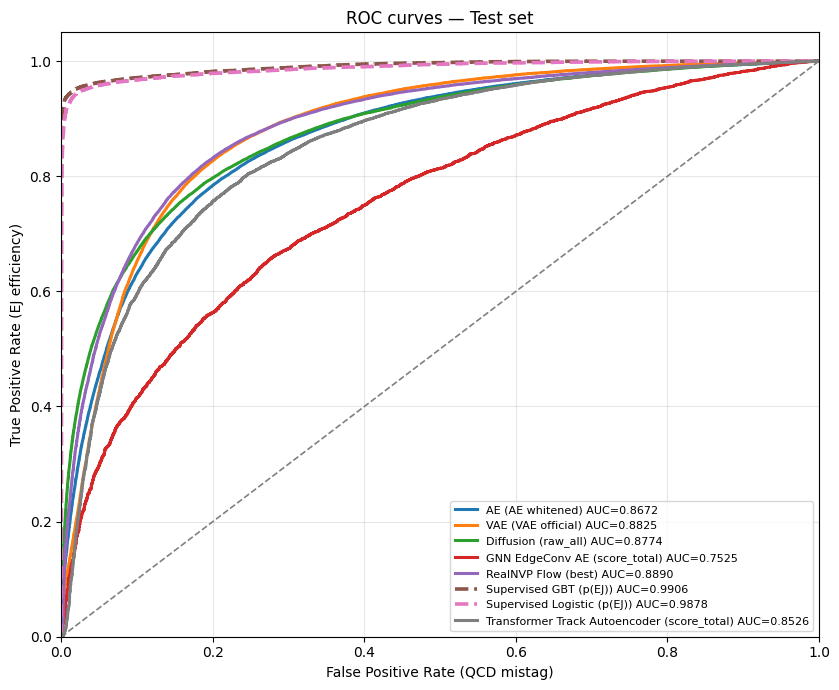

Saved: ..\outputs\task3_evaluation\plots\final_roc_curves.png


In [8]:
if len(roc_curves) and len(final_table):
    selected_pairs = set(zip(final_table["model"].astype(str), final_table["score"].astype(str)))

    plt.figure(figsize=(8.5, 7))

    for (model, score), g in roc_curves.groupby(["model", "score"]):
        if (str(model), str(score)) not in selected_pairs:
            continue
        g = g.sort_values("fpr")
        auc_val = float(g["auc"].iloc[0]) if "auc" in g else np.nan
        family = str(final_table[(final_table["model"].astype(str)==str(model)) & (final_table["score"].astype(str)==str(score))]["family"].iloc[0])
        linestyle = "--" if family == "Supervised" else "-"
        linewidth = 2.6 if family == "Supervised" else 2.2
        label_name = str(model)
        if model == "AE/VAE" and str(score).startswith("AE"):
            label_name = "AE"
        elif model == "AE/VAE" and str(score).startswith("VAE"):
            label_name = "VAE"
        plt.plot(g["fpr"], g["tpr"], linestyle=linestyle, linewidth=linewidth, label=f"{label_name} ({score}) AUC={auc_val:.4f}")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.2)
    plt.xlabel("False Positive Rate (QCD mistag)")
    plt.ylabel("True Positive Rate (EJ efficiency)")
    plt.title("ROC curves — Test set")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, loc="lower right")
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "final_roc_curves.png", dpi=250)
    plt.savefig(PLOTS_DIR / "final_roc_curves.pdf")
    plt.show()
    print("Saved:", PLOTS_DIR / "final_roc_curves.png")
else:
    print("ROC curve non disponibili.")

## 9. Plot AUC ed efficiency a mistag fissato

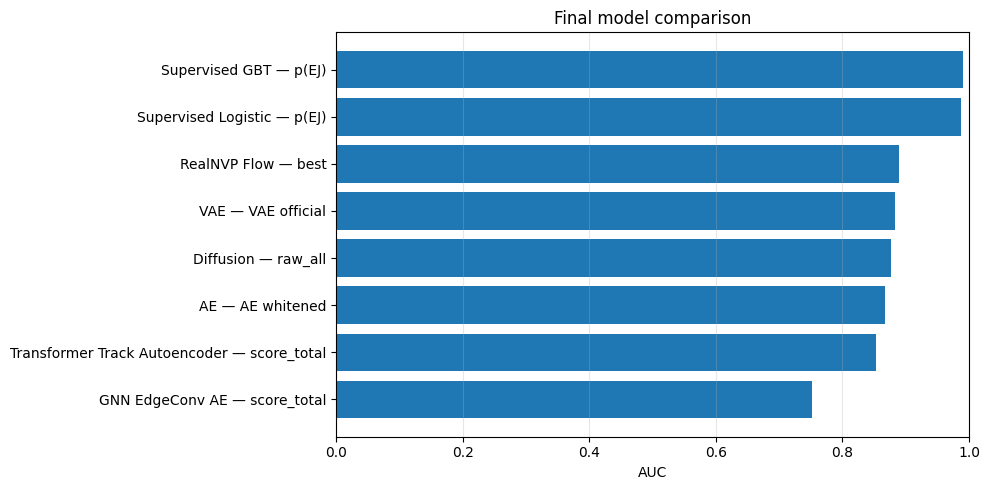

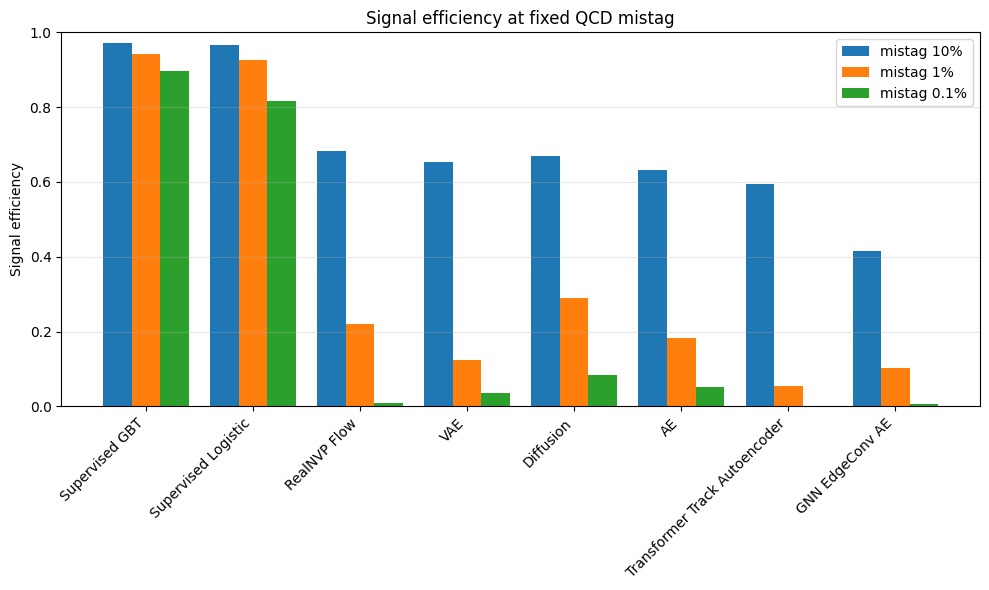

In [9]:
if len(final_table):
    plot_df = final_table.copy()
    plot_df["label"] = plot_df["display_model"].fillna(plot_df["model"]).astype(str) + " — " + plot_df["score"].astype(str)
    plot_df = plot_df.sort_values("auc", ascending=True)

    plt.figure(figsize=(10, max(5, 0.45 * len(plot_df))))
    plt.barh(plot_df["label"], plot_df["auc"])
    plt.xlabel("AUC")
    plt.title("Final model comparison")
    plt.xlim(0, 1)
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "final_auc_barplot.png", dpi=250)
    plt.show()

    eff_cols = [("eff_at_0.1_mistag", "10%"), ("eff_at_0.01_mistag", "1%"), ("eff_at_0.001_mistag", "0.1%")]
    available = [(c, lab) for c, lab in eff_cols if c in final_table.columns and final_table[c].notna().any()]
    if available:
        eff_df = final_table.copy()
        eff_df["label"] = eff_df["display_model"].fillna(eff_df["model"]).astype(str)
        x = np.arange(len(eff_df))
        width = 0.8 / len(available)
        plt.figure(figsize=(10, 6))
        for i, (col, lab) in enumerate(available):
            plt.bar(x + i*width, eff_df[col], width=width, label=f"mistag {lab}")
        plt.xticks(x + width*(len(available)-1)/2, eff_df["label"], rotation=45, ha="right")
        plt.ylabel("Signal efficiency")
        plt.title("Signal efficiency at fixed QCD mistag")
        plt.ylim(0, 1)
        plt.grid(True, axis="y", alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "final_efficiency_at_mistag.png", dpi=250)
        plt.show()

## 10. Score distributions QCD vs EJ

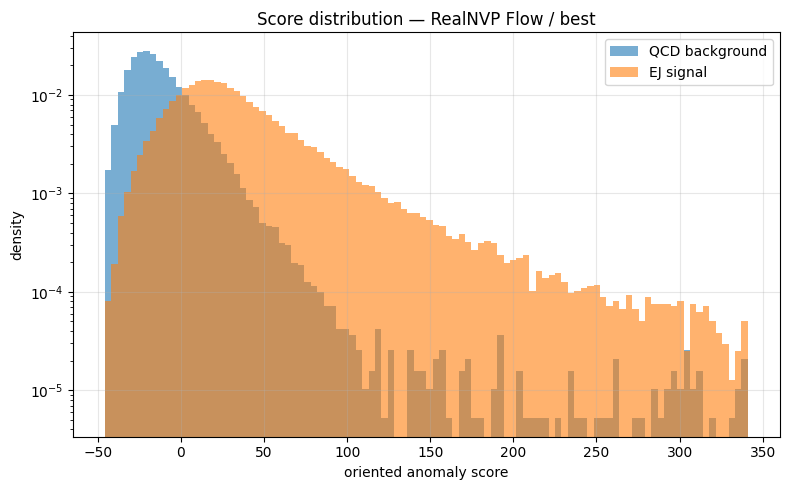

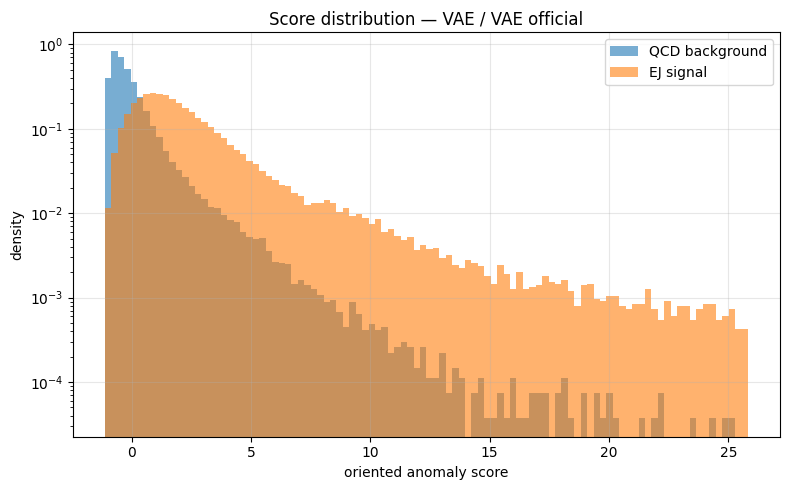

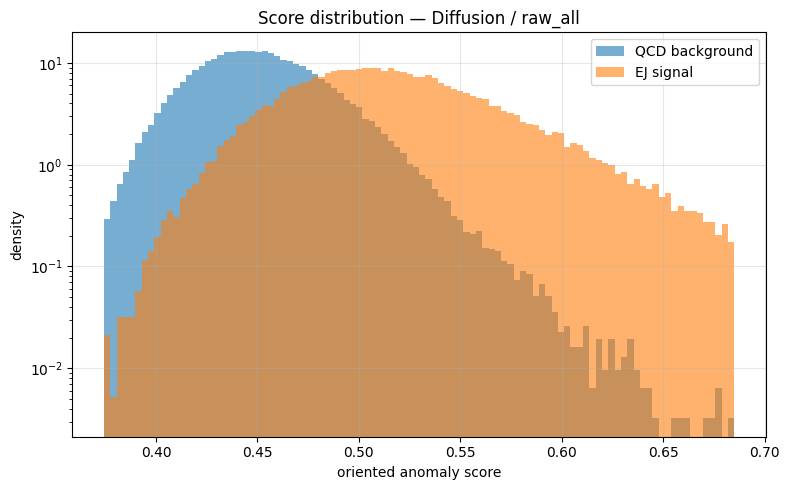

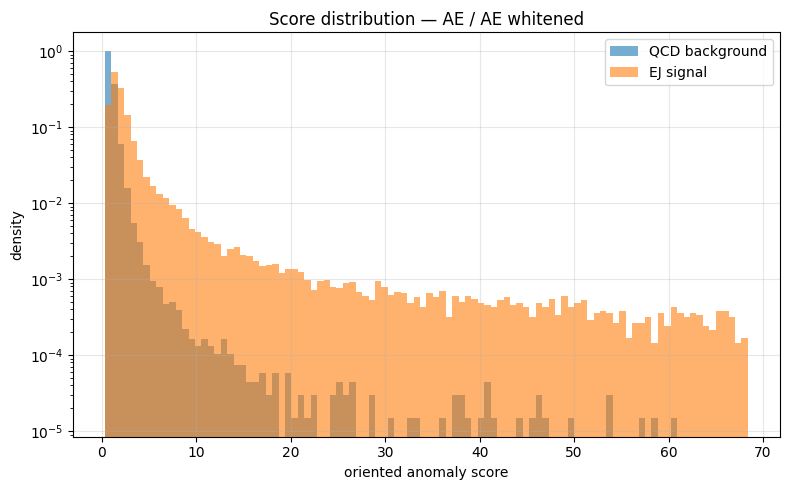

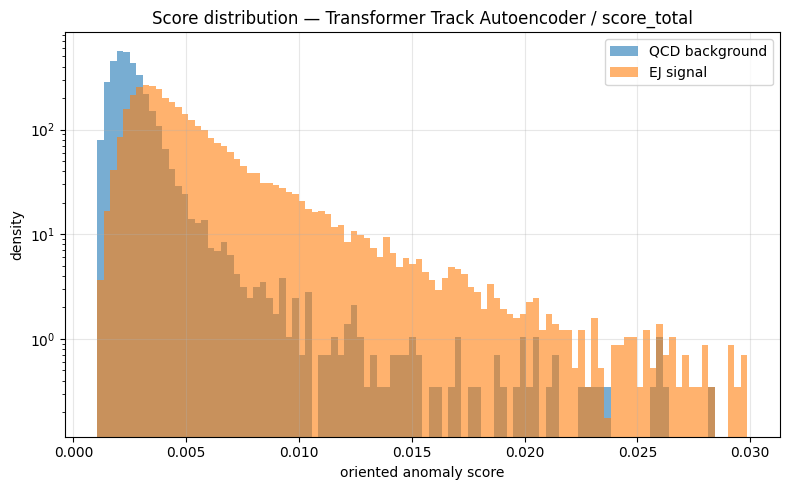

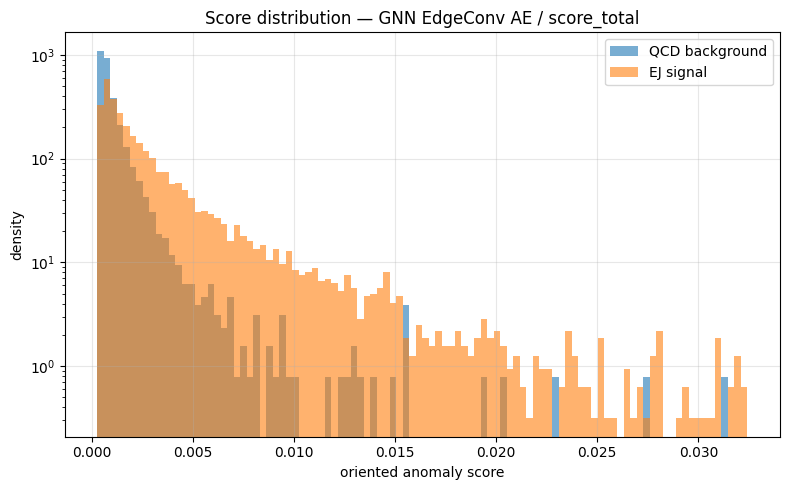

In [10]:
# Plotta distribuzioni score per i modelli selezionati, se gli score grezzi sono disponibili.

if score_records:
    for _, row in final_table.iterrows():
        key = (row["model"], row["score"])
        if key not in score_records:
            continue
        rec = score_records[key]
        bg = rec["curve"]["bg_oriented"]
        sig = rec["curve"]["sig_oriented"]
        label = row.get("display_model", row["model"])
        all_s = np.concatenate([bg, sig])
        lo = np.percentile(all_s, 0.1)
        hi = np.percentile(all_s, 99.5)
        plt.figure(figsize=(8, 5))
        plt.hist(bg, bins=100, range=(lo, hi), density=True, alpha=0.6, label="QCD background")
        plt.hist(sig, bins=100, range=(lo, hi), density=True, alpha=0.6, label="EJ signal")
        plt.yscale("log")
        plt.xlabel("oriented anomaly score")
        plt.ylabel("density")
        plt.title(f"Score distribution — {label} / {row['score']}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        safe_name = str(label).replace("/", "_").replace(" ", "_") + "_" + str(row["score"]).replace("/", "_").replace(" ", "_")
        plt.savefig(PLOTS_DIR / f"score_distribution_{safe_name}.png", dpi=200)
        plt.show()
else:
    print("Score grezzi non disponibili per distribuzioni.")

## 11. Background consistency

,comparison,auc,auc_inverted,best_auc,model,family,score
0,train QCD vs val QCD,0.507638,0.492362,0.507638,AE/VAE,AE/VAE,AE whitened
1,train QCD vs test QCD,0.507638,0.492362,0.507638,AE/VAE,AE/VAE,AE whitened
2,val QCD vs test QCD,0.500000,0.500000,0.500000,AE/VAE,AE/VAE,AE whitened
3,train QCD vs val QCD,0.499550,0.500450,0.500450,AE/VAE,AE/VAE,VAE official
4,train QCD vs test QCD,0.499550,0.500450,0.500450,AE/VAE,AE/VAE,VAE official
...,...,...,...,...,...,...,...
58,train QCD vs test QCD,0.496780,0.503220,0.503220,GNN EdgeConv AE,GNN,score_jet
59,val QCD vs test QCD,0.487077,0.512923,0.512923,GNN EdgeConv AE,GNN,score_jet
60,train QCD vs val QCD,0.514646,0.485354,0.514646,GNN EdgeConv AE,GNN,score_track
61,train QCD vs test QCD,0.509657,0.490343,0.509657,GNN EdgeConv AE,GNN,score_track


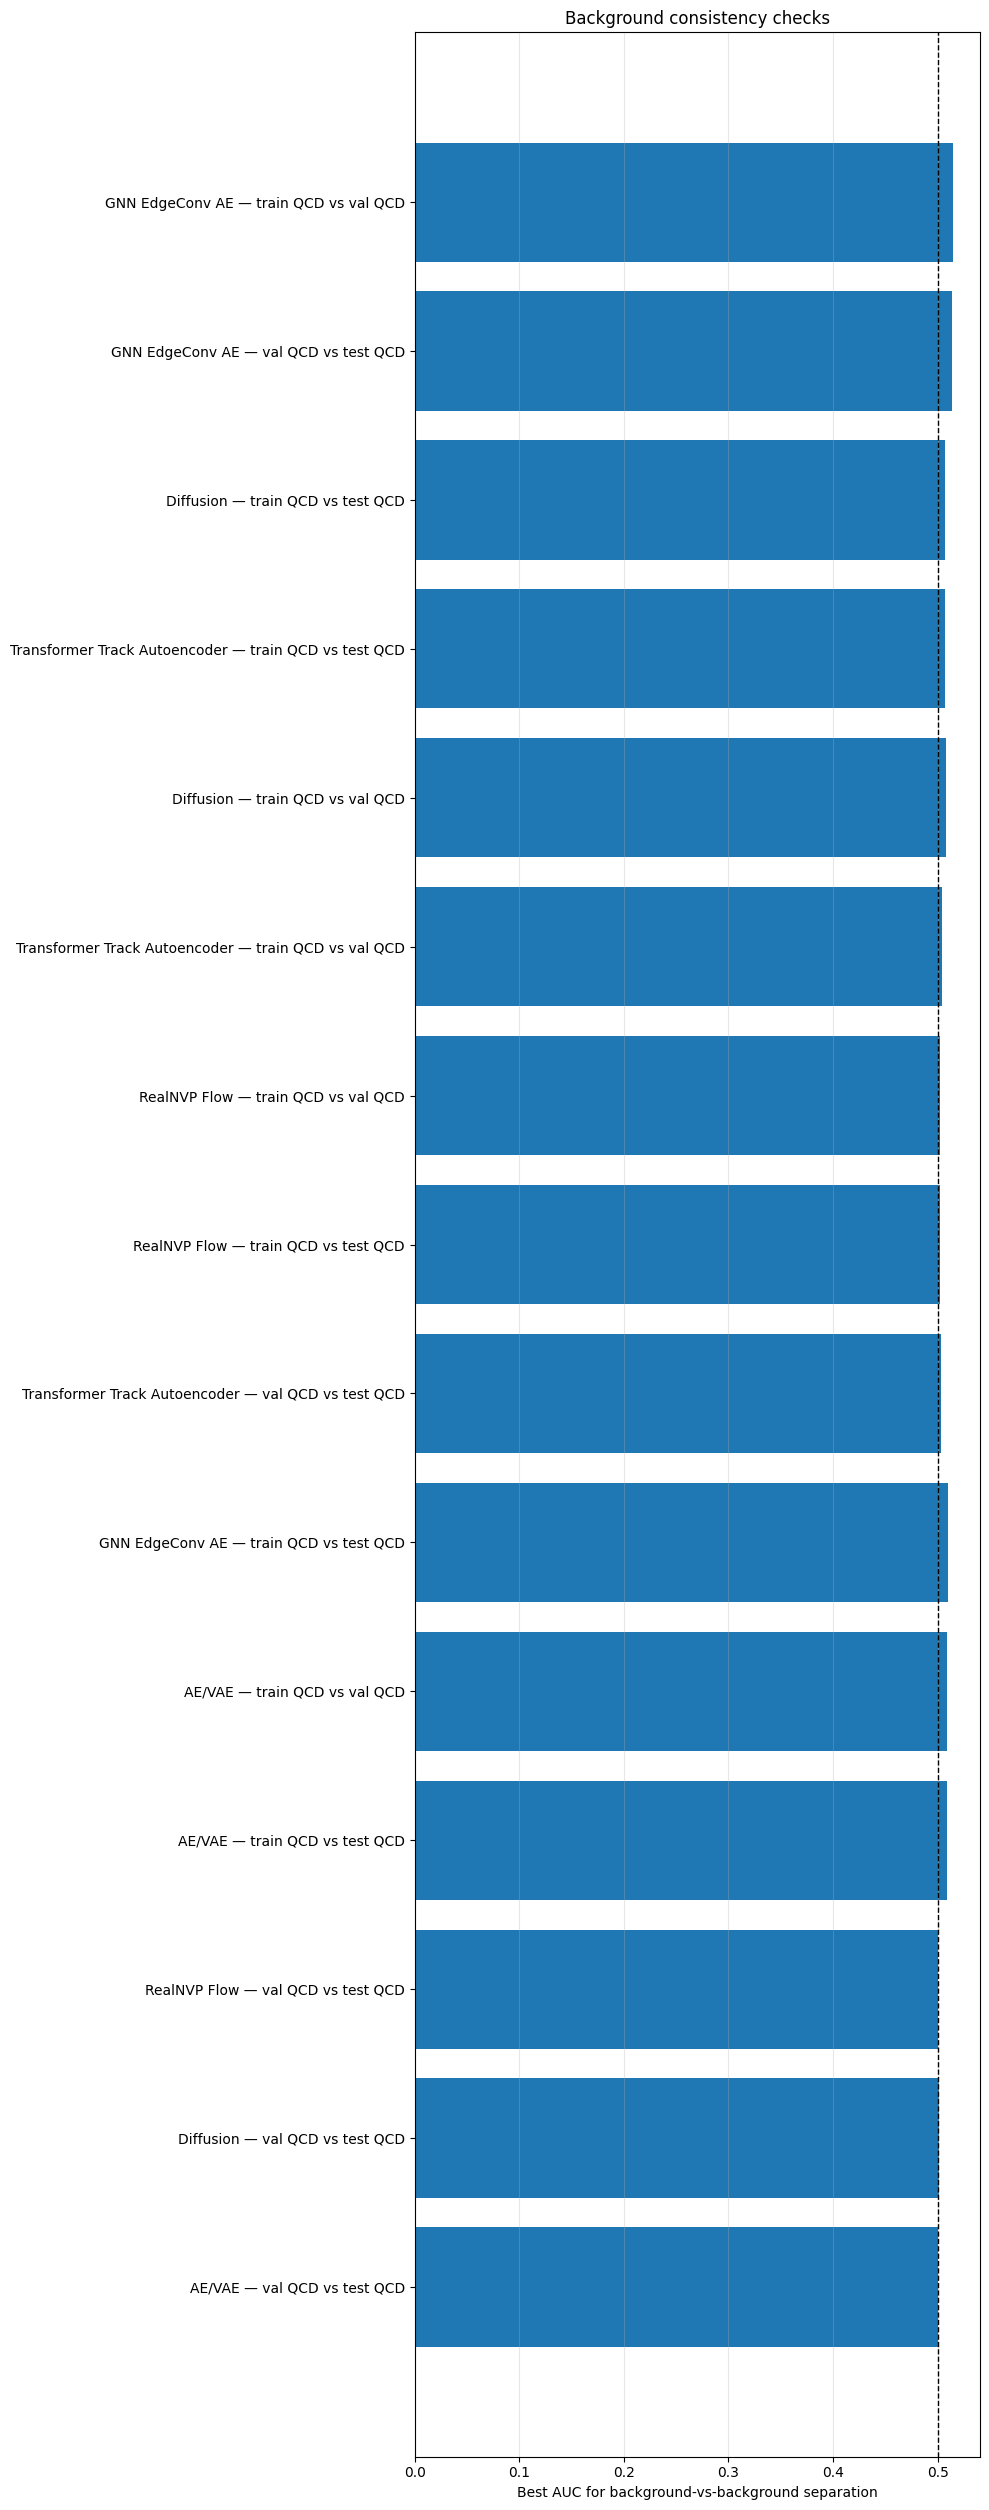

In [11]:
if len(background_checks):
    # Normalizzazione colonne comuni.
    if "best_auc" not in background_checks.columns and {"auc", "auc_inverted"}.issubset(background_checks.columns):
        background_checks["best_auc"] = np.maximum(pd.to_numeric(background_checks["auc"], errors="coerce"), pd.to_numeric(background_checks["auc_inverted"], errors="coerce"))
    background_checks.to_csv(TASK3_DIR / "background_checks_summary.csv", index=False)
    display(background_checks)

    if "best_auc" in background_checks.columns:
        plt.figure(figsize=(10, max(4, 0.4 * len(background_checks))))
        labels = background_checks.get("model", pd.Series(["model"]*len(background_checks))).astype(str) + " — " + background_checks.get("comparison", pd.Series(["bg check"]*len(background_checks))).astype(str)
        order = np.argsort(pd.to_numeric(background_checks["best_auc"], errors="coerce"))
        plt.barh(labels.iloc[order], pd.to_numeric(background_checks["best_auc"], errors="coerce").iloc[order])
        plt.axvline(0.5, linestyle="--", color="black", linewidth=1)
        plt.xlabel("Best AUC for background-vs-background separation")
        plt.title("Background consistency checks")
        plt.grid(True, axis="x", alpha=0.3)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "background_consistency_checks.png", dpi=250)
        plt.show()
else:
    print("Nessun background check disponibile.")

## 12. Interpretabilità: feature attribution disponibili

In [12]:
# Colleziona feature importance / reconstruction error prodotti dai notebook modello, se disponibili.
importance_files = [
    OUTPUTS_DIR / "ae_vae" / "ae_vae_feature_reconstruction_errors.csv",
    OUTPUTS_DIR / "normalizing_flow" / "realnvp_feature_importance.csv",
    OUTPUTS_DIR / "diffusion" / "diffusion_feature_importance.csv",
    OUTPUTS_DIR / "transformer_deep_svdd" / "transformer_deep_svdd_feature_importance.csv",
    OUTPUTS_DIR / "transformer_track_autoencoder" / "transformer_track_autoencoder_feature_reco_errors.csv",
    OUTPUTS_DIR / "gnn" / "gnn_edgeconv_ae_feature_reconstruction_errors.csv",
    OUTPUTS_DIR / "gnn" / "gnn_edgeconv_ae_permutation_importance.csv",
    OUTPUTS_DIR / "gnn_edgeconv_ae" / "gnn_edgeconv_ae_feature_reconstruction_errors.csv",
    OUTPUTS_DIR / "gnn_edgeconv_ae" / "gnn_edgeconv_ae_permutation_importance.csv",
    SUP_DIR / "supervised_logistic_feature_coefficients.csv",
    SUP_DIR / "supervised_gbt_permutation_importance.csv",
]

available_importance = []
for p in importance_files:
    if p.exists():
        df = safe_read_csv(p)
        if df is not None:
            available_importance.append({"file": str(p), "n_rows": len(df), "columns": list(df.columns)})
            print("[OK]", p)
            display(df.head(15))
    else:
        print("[MISSING]", p)

pd.DataFrame(available_importance).to_csv(TASK3_DIR / "available_interpretability_files.csv", index=False)

[MISSING] ..\outputs\ae_vae\ae_vae_feature_reconstruction_errors.csv
[MISSING] ..\outputs\normalizing_flow\realnvp_feature_importance.csv
[MISSING] ..\outputs\diffusion\diffusion_feature_importance.csv
[MISSING] ..\outputs\transformer_deep_svdd\transformer_deep_svdd_feature_importance.csv
[OK] ..\outputs\transformer_track_autoencoder\transformer_track_autoencoder_feature_reco_errors.csv


,feature_type,feature,qcd_test_mse,signal_mse,delta_signal_minus_qcd,ratio_signal_over_qcd
0,jet,Tau4_clusterSoftDrop,0.002755,0.022532,0.019777,8.177584
1,jet,Tau3_clusterSoftDrop,0.003330,0.018377,0.015047,5.518514
2,jet,Tau2_clusterSoftDrop,0.002715,0.009144,0.006430,3.368594
3,jet,mass,0.003691,0.009931,0.006240,2.690329
4,jet,Tau1_clusterSoftDrop,0.002380,0.008466,0.006086,3.556877
5,jet,energy,0.001664,0.004636,0.002972,2.786053
6,jet,Qw_clusterSoftDrop,0.005660,0.008420,0.002760,1.487625
7,jet,pt,0.001784,0.004532,0.002748,2.540345
8,jet,eta,0.001496,0.004107,0.002611,2.744629
9,track,d0_log1p,0.002410,0.003797,0.001387,1.575545


[OK] ..\outputs\gnn\gnn_edgeconv_ae_feature_reconstruction_errors.csv


,feature_type,feature,mse_bkg,mse_sig,ratio_sig_over_bkg,delta_sig_minus_bkg
0,jet,Tau3_clusterSoftDrop,0.001848,0.018762,10.150332,0.016913
1,jet,Tau2_clusterSoftDrop,0.000726,0.004946,6.811820,0.004220
2,jet,Tau4_clusterSoftDrop,0.001469,0.009077,6.180110,0.007608
3,jet,Tau1_clusterSoftDrop,0.000698,0.002689,3.851400,0.001991
4,jet,mass,0.000785,0.001526,1.943294,0.000740
5,jet,eta,0.000787,0.001502,1.910022,0.000716
6,jet,ECF2_clusterSoftDrop,0.001141,0.001965,1.721614,0.000824
7,jet,energy,0.000723,0.001004,1.388022,0.000281
8,track,numberOfPixelHits,0.000474,0.000608,1.283011,0.000134
9,jet,Qw_clusterSoftDrop,0.000921,0.001168,1.267109,0.000246


[MISSING] ..\outputs\gnn\gnn_edgeconv_ae_permutation_importance.csv
[MISSING] ..\outputs\gnn_edgeconv_ae\gnn_edgeconv_ae_feature_reconstruction_errors.csv
[MISSING] ..\outputs\gnn_edgeconv_ae\gnn_edgeconv_ae_permutation_importance.csv
[OK] ..\outputs\supervised_baseline\supervised_logistic_feature_coefficients.csv


,feature,coef,abs_coef
0,pt,-5.362147,5.362147
1,Tau21_clusterSoftDrop,5.002290,5.002290
2,ECF1_clusterSoftDrop,4.922717,4.922717
3,C2_clusterSoftDrop,-3.836422,3.836422
4,ECF2_clusterSoftDrop,-3.121542,3.121542
5,log_n_tracks,-2.543014,2.543014
6,Tau3_clusterSoftDrop,2.231044,2.231044
7,radiusOfFirstHit_mean,1.989468,1.989468
8,Tau4_clusterSoftDrop,-1.932557,1.932557
9,mass,1.843965,1.843965


[OK] ..\outputs\supervised_baseline\supervised_gbt_permutation_importance.csv


,feature,importance_mean,importance_std
0,log_n_tracks,0.014019,0.001067
1,pt,0.003157,0.000113
2,numberOfInnermostPixelLayerHits_mean,0.003057,0.000255
3,Tau2_clusterSoftDrop,0.001382,0.000113
4,D2_clusterSoftDrop,0.001229,0.000259
5,radiusOfFirstHit_median,0.001017,0.000277
6,Tau1_clusterSoftDrop,0.000944,0.000087
7,pt_log1p_std,0.000919,0.000148
8,C2_clusterSoftDrop,0.000787,0.000127
9,mass,0.000695,0.000203


## 13. Latent-space PCA, se embedding disponibili

[SKIP] PCA AE/VAE: embeddings non trovati
[SKIP] PCA RealNVP Flow: embeddings non trovati
[SKIP] PCA Diffusion: embeddings non trovati


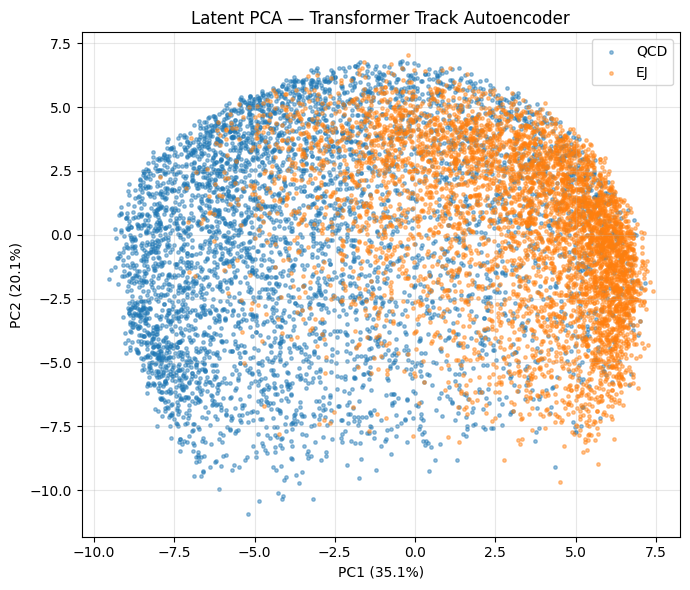

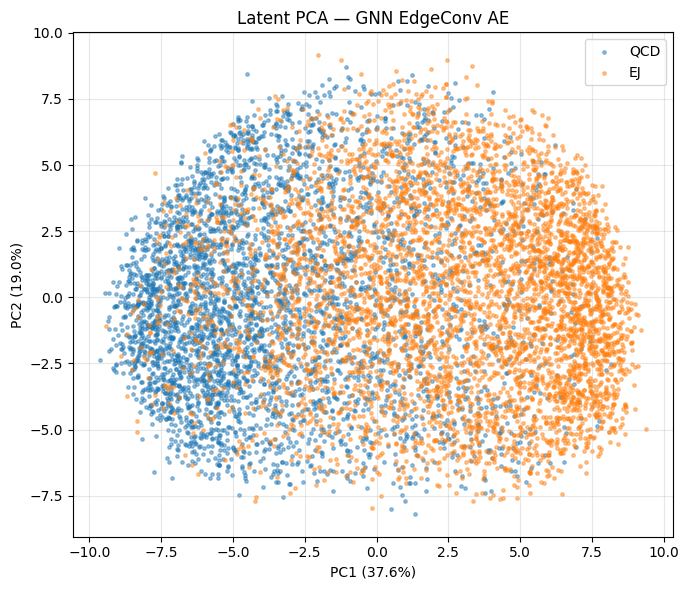

In [13]:
def plot_pca_if_available(model_name, npz, bg_keys, sig_keys, output_name, max_points=5000):
    Z_bg = get_first_array(npz, bg_keys)
    Z_sig = get_first_array(npz, sig_keys)
    if Z_bg is None or Z_sig is None:
        print(f"[SKIP] PCA {model_name}: embeddings non trovati")
        return None
    Z_bg = np.asarray(Z_bg, dtype=np.float32)
    Z_sig = np.asarray(Z_sig, dtype=np.float32)
    rng = np.random.default_rng(SEED)
    n_b = min(max_points, Z_bg.shape[0])
    n_s = min(max_points, Z_sig.shape[0])
    idx_b = rng.choice(Z_bg.shape[0], n_b, replace=False)
    idx_s = rng.choice(Z_sig.shape[0], n_s, replace=False)
    X = np.concatenate([Z_bg[idx_b], Z_sig[idx_s]], axis=0)
    y = np.concatenate([np.zeros(n_b), np.ones(n_s)])
    Xs = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=SEED)
    X2 = pca.fit_transform(Xs)
    plt.figure(figsize=(7, 6))
    plt.scatter(X2[y == 0, 0], X2[y == 0, 1], s=6, alpha=0.45, label="QCD")
    plt.scatter(X2[y == 1, 0], X2[y == 1, 1], s=6, alpha=0.45, label="EJ")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    plt.title(f"Latent PCA — {model_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / output_name, dpi=200)
    plt.show()
    return pca.explained_variance_ratio_

pca_rows = []
for model_name, pack in loaded.items():
    npz = pack["scores"]
    if npz is None:
        continue
    evr = plot_pca_if_available(
        model_name,
        npz,
        bg_keys=["Z_bkg_test", "Z_bg", "Z_test_background"],
        sig_keys=["Z_sig", "Z_signal", "Z_test_signal"],
        output_name=f"latent_pca_{model_name.replace(' ', '_').replace('/', '_')}.png",
    )
    if evr is not None:
        pca_rows.append({"model": model_name, "pc1_var": float(evr[0]), "pc2_var": float(evr[1])})

pd.DataFrame(pca_rows).to_csv(TASK3_DIR / "latent_pca_summary.csv", index=False)

## 14. Truth-level dark-pion information

## Lettura metadata truth-level separati per la sensitivity LLP

Legge i metadata truth-level salvati separatamente dal preprocessing.

I modelli non usano queste variabili durante il training. Qui vengono usate solo per la valutazione finale, cioè per studiare come cambia la performance in funzione di decay length e massa dei dark pion.

La scelta di tenerle in un file separato evita leakage e rende più chiara la distinzione tra:

- feature fisiche usate dai modelli;
- informazioni truth-level usate solo per la valutazione.

In [14]:
# ============================================================
# Lettura truth-level metadata separati
# ============================================================

truth_df = None
truth_source = None

truth_candidates = [
    PROCESSED_DIR / "truth_dark_pion_signal_metadata.csv",
    PROCESSED_DIR / "truth_dark_pion_signal_metadata.npz",
]

for p in truth_candidates:
    p = Path(p)

    if not p.exists():
        continue

    if p.suffix == ".csv":
        tmp = pd.read_csv(p)

        truth_cols = [
            c for c in tmp.columns
            if c.startswith("truth_dark_pion_") or c == "truth_signal_eventNumber"
        ]

        if truth_cols:
            truth_df = tmp[truth_cols].copy()
            truth_source = str(p)
            break

    elif p.suffix == ".npz":
        npz = safe_load_npz(p)

        if npz is None:
            continue

        arrays = {}

        for k in npz.keys():
            if k.startswith("truth_dark_pion_") or k == "truth_signal_eventNumber":
                arr = np.asarray(npz[k])

                if arr.ndim == 1:
                    arrays[k] = arr

        if arrays:
            # Tengo solo array con la lunghezza più comune.
            lengths = {k: len(v) for k, v in arrays.items()}
            mode_len = pd.Series(lengths).mode().iloc[0]

            arrays = {
                k: v for k, v in arrays.items()
                if len(v) == mode_len
            }

            truth_df = pd.DataFrame(arrays)
            truth_source = str(p)
            break

if truth_df is None:
    print("Truth dark pion information non trovata.")
    print("Esegui prima la cella di preprocessing che crea:")
    print(PROCESSED_DIR / "truth_dark_pion_signal_metadata.csv")
    print(PROCESSED_DIR / "truth_dark_pion_signal_metadata.npz")

else:
    truth_df = truth_df.replace([np.inf, -np.inf], np.nan)

    print("Truth source:", truth_source)
    print("truth_df shape:", truth_df.shape)

    useful_cols = [
        c for c in truth_df.columns
        if any(x in c for x in ["Lxy", "Lxy_prod", "mass", "truth_dark_pion_n"])
    ]

    print("Truth columns useful for LLP sensitivity:")
    print(useful_cols)

    if useful_cols:
        display(truth_df[useful_cols].describe().T)
    else:
        display(truth_df.describe().T)

    truth_df.to_csv(
        TASK3_DIR / "truth_dark_pion_per_jet.csv",
        index=False,
    )

    print("Saved:", TASK3_DIR / "truth_dark_pion_per_jet.csv")

Truth source: ..\processed\truth_dark_pion_signal_metadata.csv
truth_df shape: (61966, 42)
Truth columns useful for LLP sensitivity:
['truth_dark_pion_n', 'truth_dark_pion_Lxy_mean', 'truth_dark_pion_Lxy_median', 'truth_dark_pion_Lxy_q90', 'truth_dark_pion_Lxy_max', 'truth_dark_pion_Lxy_prod_mean', 'truth_dark_pion_Lxy_prod_median', 'truth_dark_pion_Lxy_prod_q90', 'truth_dark_pion_Lxy_prod_max', 'truth_dark_pion_mass_mean', 'truth_dark_pion_mass_median', 'truth_dark_pion_mass_q90', 'truth_dark_pion_mass_max']


,count,mean,std,min,25%,50%,75%,max
truth_dark_pion_n,61966.0,4.473001,2.344667,0.000000,3.000000,4.000000,6.000000,19.000000
truth_dark_pion_Lxy_mean,60478.0,116.081486,46.030114,0.103367,85.704740,114.147793,144.060665,299.996000
truth_dark_pion_Lxy_median,60478.0,109.019965,55.865045,0.103367,67.068993,102.462983,144.453035,299.996000
truth_dark_pion_Lxy_q90,60478.0,184.813483,63.850092,0.103367,144.183457,194.962995,234.333430,299.996000
truth_dark_pion_Lxy_max,60478.0,206.401595,70.871586,0.103367,161.130815,221.902140,264.891192,299.999900
truth_dark_pion_Lxy_prod_mean,60478.0,0.707069,0.008498,0.673220,0.701378,0.707029,0.712865,0.739823
truth_dark_pion_Lxy_prod_median,60478.0,0.707069,0.008498,0.673220,0.701378,0.707029,0.712865,0.739823
truth_dark_pion_Lxy_prod_q90,60478.0,0.707069,0.008498,0.673220,0.701378,0.707029,0.712865,0.739823
truth_dark_pion_Lxy_prod_max,60478.0,0.707069,0.008498,0.673220,0.701378,0.707029,0.712865,0.739823
truth_dark_pion_mass_mean,60478.0,10000.000000,0.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000


Saved: ..\outputs\task3_evaluation\truth_dark_pion_per_jet.csv


## 15. Sensitivity vs LLP decay length e mass

Modello usato per sensitivity: RealNVP Flow / best
Threshold @ 1% QCD mistag: 56.80837615966805
Variabili truth usate per sensitivity:
  truth_dark_pion_Lxy_median  ->  Lxy_median
  truth_dark_pion_Lxy_mean  ->  Lxy_mean
  truth_dark_pion_Lxy_q90  ->  Lxy_q90
  truth_dark_pion_Lxy_max  ->  Lxy_max
  truth_dark_pion_Lxy_prod_median  ->  Lxy_prod_median
  truth_dark_pion_Lxy_prod_mean  ->  Lxy_prod_mean
  truth_dark_pion_Lxy_prod_q90  ->  Lxy_prod_q90
  truth_dark_pion_Lxy_prod_max  ->  Lxy_prod_max
  truth_dark_pion_mass_median  ->  mass_median
  truth_dark_pion_mass_mean  ->  mass_mean
  truth_dark_pion_mass_q90  ->  mass_q90
  truth_dark_pion_mass_max  ->  mass_max
  truth_dark_pion_n  ->  n_dark_pions
[SKIP] truth_dark_pion_mass_median costante o quasi costante
[SKIP] truth_dark_pion_mass_mean costante o quasi costante
[SKIP] truth_dark_pion_mass_q90 costante o quasi costante
[SKIP] truth_dark_pion_mass_max costante o quasi costante


,model,score,variable,source_column,mistag,threshold,bin_low,bin_high,bin_center,n_signal,signal_efficiency
0,RealNVP Flow,best,Lxy_median,truth_dark_pion_Lxy_median,0.01,56.808376,0.103367,59.159197,29.631282,12096,0.155010
1,RealNVP Flow,best,Lxy_median,truth_dark_pion_Lxy_median,0.01,56.808376,59.159197,88.223412,73.691305,12095,0.207524
2,RealNVP Flow,best,Lxy_median,truth_dark_pion_Lxy_median,0.01,56.808376,88.223412,117.782958,103.003185,12096,0.236442
3,RealNVP Flow,best,Lxy_median,truth_dark_pion_Lxy_median,0.01,56.808376,117.782958,155.507728,136.645343,12095,0.253741
4,RealNVP Flow,best,Lxy_median,truth_dark_pion_Lxy_median,0.01,56.808376,155.507728,299.996000,227.751864,12096,0.263558
5,RealNVP Flow,best,Lxy_mean,truth_dark_pion_Lxy_mean,0.01,56.808376,0.103367,78.649970,39.376668,12096,0.154597
6,RealNVP Flow,best,Lxy_mean,truth_dark_pion_Lxy_mean,0.01,56.808376,78.649970,103.306831,90.978401,12095,0.199339
7,RealNVP Flow,best,Lxy_mean,truth_dark_pion_Lxy_mean,0.01,56.808376,103.306831,125.033977,114.170404,12096,0.230241
8,RealNVP Flow,best,Lxy_mean,truth_dark_pion_Lxy_mean,0.01,56.808376,125.033977,151.679790,138.356883,12095,0.267962
9,RealNVP Flow,best,Lxy_mean,truth_dark_pion_Lxy_mean,0.01,56.808376,151.679790,299.996000,225.837895,12096,0.264137


Saved: ..\outputs\task3_evaluation\truth_dark_pion_sensitivity.csv


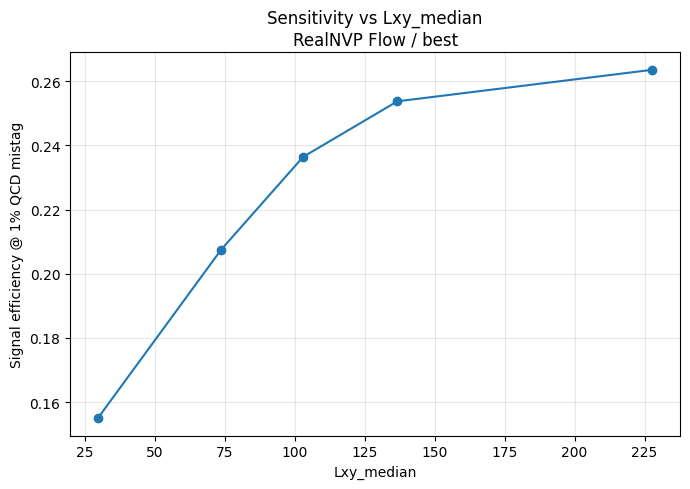

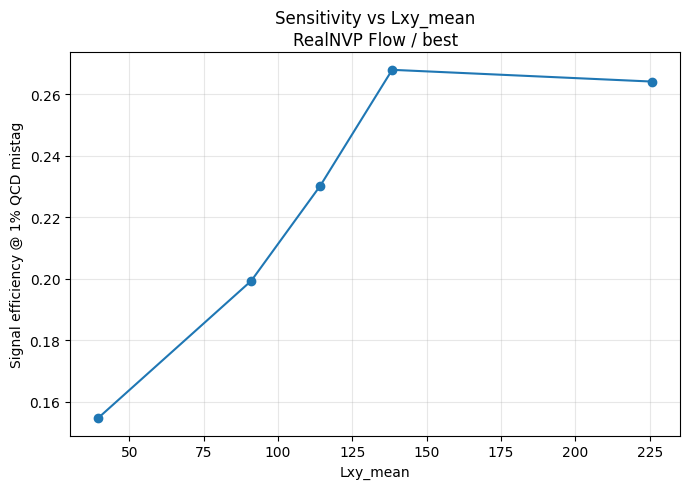

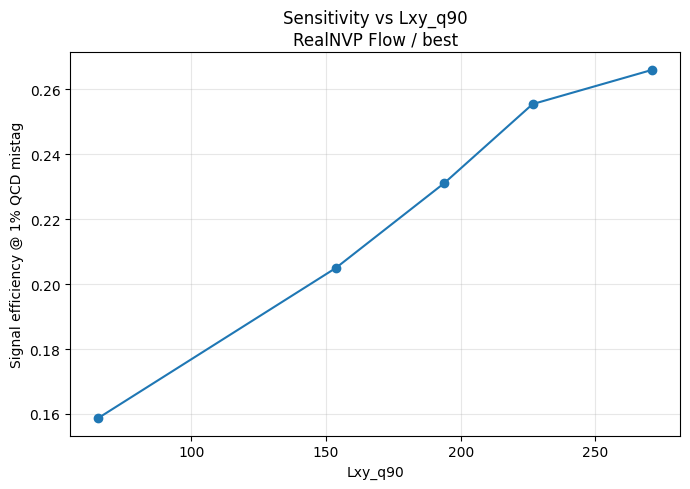

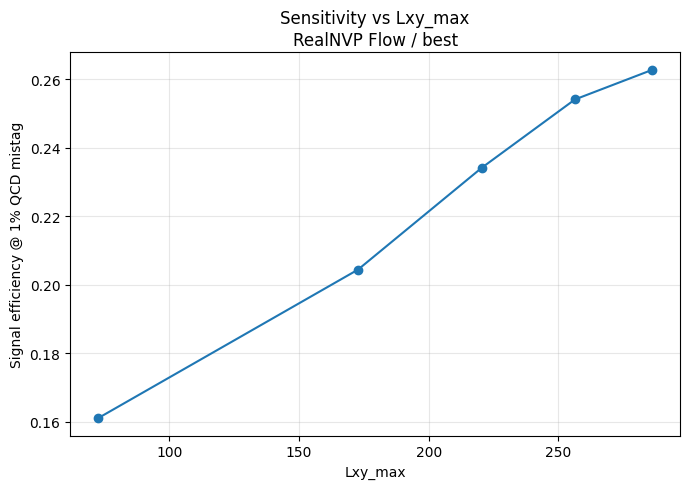

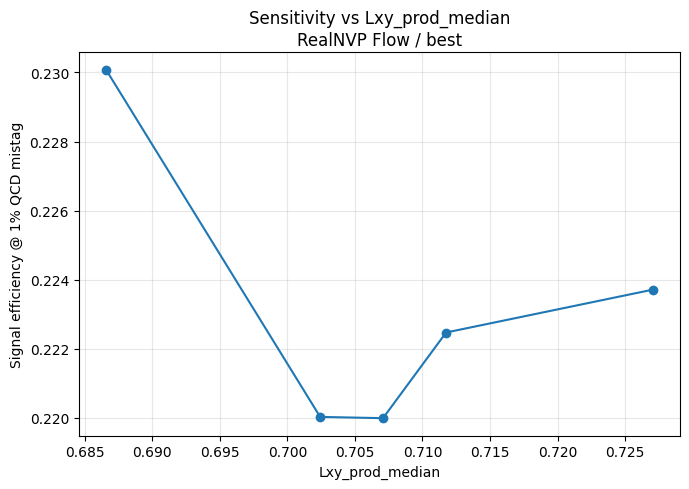

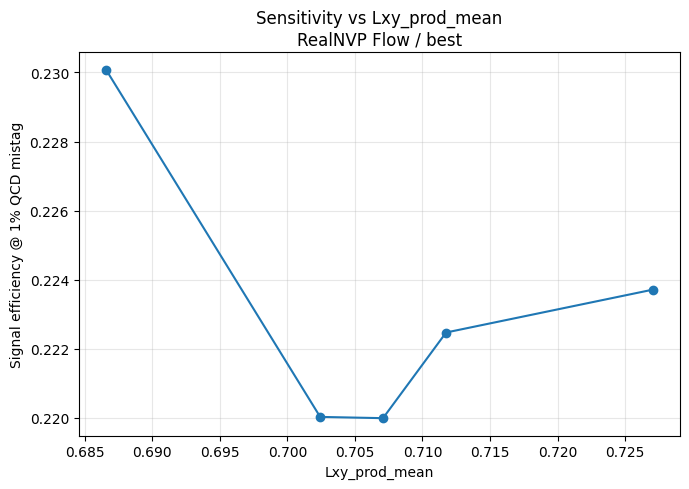

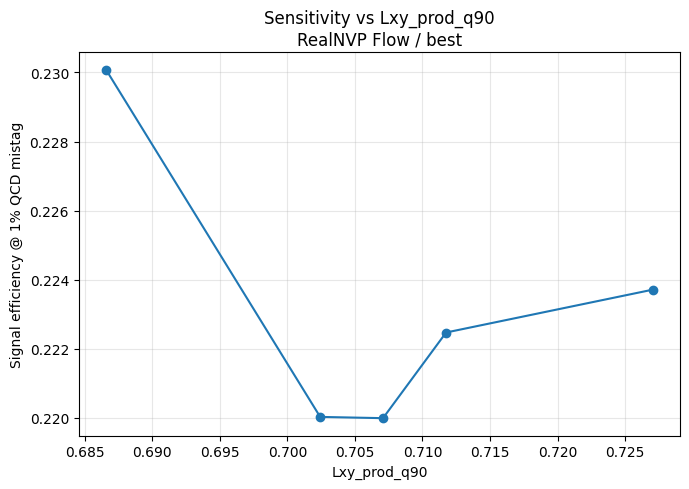

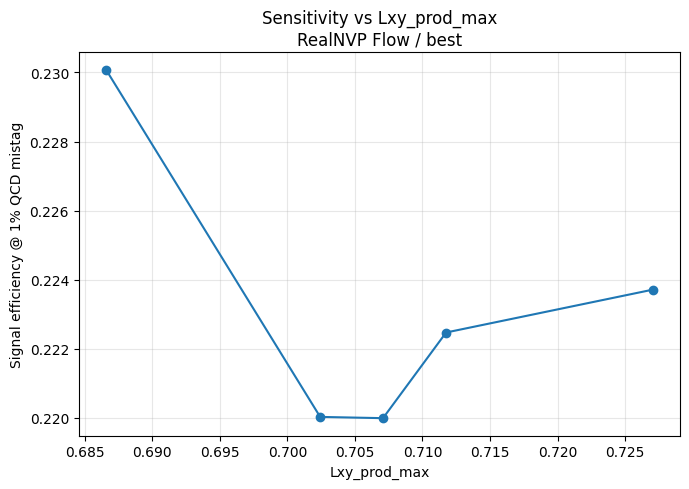

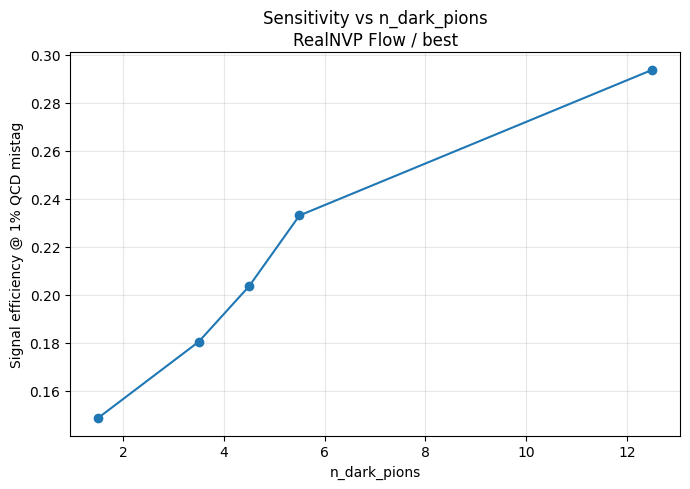

In [ ]:
# ============================================================
# Sensitivity vs LLP decay length / mass — versione robusta
# ============================================================

sensitivity_rows = []

sensitivity_columns = [
    "model",
    "score",
    "variable",
    "mistag",
    "threshold",
    "bin_low",
    "bin_high",
    "bin_center",
    "n_signal",
    "signal_efficiency",
]

if truth_df is None or len(final_table) == 0:
    print("Sensitivity saltata: manca truth_df o final_table.")

    df_sensitivity = pd.DataFrame(columns=sensitivity_columns)
    df_sensitivity.to_csv(
        TASK3_DIR / "truth_dark_pion_sensitivity.csv",
        index=False,
    )

else:
    # ------------------------------------------------------------
    # 1. Scelgo il miglior modello non supervisionato con score grezzi.
    # ------------------------------------------------------------
    # Per fare la sensitivity servono gli score evento-per-evento del segnale.
    # Se un modello è presente solo come results.csv aggregato, non basta.
    # ------------------------------------------------------------

    unsup = final_table[final_table["family"] != "Supervised"].copy()

    if len(unsup) == 0:
        candidates = final_table.sort_values("auc", ascending=False).copy()
    else:
        candidates = unsup.sort_values("auc", ascending=False).copy()

    best_row = None

    for _, row in candidates.iterrows():
        key = (row["model"], row["score"])

        if key in score_records:
            best_row = row
            break

    if best_row is None:
        print("Score grezzi non disponibili per nessun modello adatto. Sensitivity saltata.")

        df_sensitivity = pd.DataFrame(columns=sensitivity_columns)
        df_sensitivity.to_csv(
            TASK3_DIR / "truth_dark_pion_sensitivity.csv",
            index=False,
        )

    else:
        best_model = best_row["model"]
        best_score = best_row["score"]

        print("Modello usato per sensitivity:", best_model, "/", best_score)

        rec = score_records[(best_model, best_score)]

        bg = np.asarray(rec["curve"]["bg_oriented"], dtype=np.float64)
        sig = np.asarray(rec["curve"]["sig_oriented"], dtype=np.float64)

        # ------------------------------------------------------------
        # 2. Allineamento minimale tra score signal e truth metadata.
        # ------------------------------------------------------------
        # Per una sensitivity perfetta, score e truth devono riferirsi agli stessi
        # eventi nello stesso ordine. Qui uso la lunghezza minima per evitare crash.
        # Nel run finale è meglio usare MAX_SIGNAL_EVENTS=None nei notebook modello.
        # ------------------------------------------------------------

        n = min(len(sig), len(truth_df))

        if n < len(sig) or n < len(truth_df):
            print(
                f"[WARN] allineamento per lunghezza minima: "
                f"score_sig={len(sig)}, truth={len(truth_df)}, uso n={n}"
            )
            print(
                "[WARN] Per il run finale, meglio avere score signal e truth metadata "
                "con stessa lunghezza e stesso ordine."
            )

        sig = sig[:n]
        truth_use = truth_df.iloc[:n].copy()

        # Soglia corrispondente a 1% QCD mistag.
        threshold = np.quantile(bg, 0.99)

        print("Threshold @ 1% QCD mistag:", float(threshold))

        # ------------------------------------------------------------
        # 3. Ricerca robusta delle variabili truth.
        # ------------------------------------------------------------
        # Supporto sia i nomi nuovi prefissati sia eventuali nomi vecchi.
        # ------------------------------------------------------------

        preferred_candidates = [
            ("truth_dark_pion_Lxy_median", "Lxy_median"),
            ("truth_dark_pion_Lxy_mean", "Lxy_mean"),
            ("truth_dark_pion_Lxy_q90", "Lxy_q90"),
            ("truth_dark_pion_Lxy_max", "Lxy_max"),

            ("truth_dark_pion_Lxy_prod_median", "Lxy_prod_median"),
            ("truth_dark_pion_Lxy_prod_mean", "Lxy_prod_mean"),
            ("truth_dark_pion_Lxy_prod_q90", "Lxy_prod_q90"),
            ("truth_dark_pion_Lxy_prod_max", "Lxy_prod_max"),

            ("truth_dark_pion_mass_median", "mass_median"),
            ("truth_dark_pion_mass_mean", "mass_mean"),
            ("truth_dark_pion_mass_q90", "mass_q90"),
            ("truth_dark_pion_mass_max", "mass_max"),

            ("truth_dark_pion_n", "n_dark_pions"),
            ("n_truth_dark_pions", "n_dark_pions"),
        ]

        selected_variables = []

        for col, label in preferred_candidates:
            if col in truth_use.columns:
                selected_variables.append((col, label))

        # Fallback: se i nomi non sono esattamente quelli attesi,
        # prendo comunque colonne truth numeriche che contengono Lxy, mass o pion_n.
        if not selected_variables:
            for col in truth_use.columns:
                col_low = str(col).lower()

                if not col_low.startswith("truth_dark_pion"):
                    continue

                if any(token in col_low for token in ["lxy", "mass", "pion_n"]):
                    selected_variables.append((col, col))

        # Rimuovo duplicati mantenendo ordine.
        seen = set()
        selected_variables_unique = []

        for col, label in selected_variables:
            if col not in seen:
                selected_variables_unique.append((col, label))
                seen.add(col)

        selected_variables = selected_variables_unique

        print("Variabili truth usate per sensitivity:")
        if selected_variables:
            for col, label in selected_variables:
                print(f"  {col}  ->  {label}")
        else:
            print("  Nessuna variabile LLP trovata in truth_df.")
            print("  Colonne disponibili:")
            print(list(truth_use.columns))

        # ------------------------------------------------------------
        # 4. Efficiency del segnale in bin di ogni variabile LLP.
        # ------------------------------------------------------------

        for col, label in selected_variables:
            values = pd.to_numeric(truth_use[col], errors="coerce").to_numpy(dtype=np.float64)

            finite = np.isfinite(values) & np.isfinite(sig)

            values_f = values[finite]
            sig_f = sig[finite]

            if len(values_f) < 10:
                print("[SKIP]", col, "troppi pochi valori finiti:", len(values_f))
                continue

            if len(np.unique(np.round(values_f, 6))) < 3:
                print("[SKIP]", col, "costante o quasi costante")
                continue

            # 5 bin quantilici: ogni bin contiene circa lo stesso numero di eventi.
            edges = np.unique(np.quantile(values_f, np.linspace(0, 1, 6)))

            if len(edges) < 3:
                print("[SKIP]", col, "bin non costruibili")
                continue

            for i in range(len(edges) - 1):
                lo = edges[i]
                hi = edges[i + 1]

                if i == len(edges) - 2:
                    m = (values_f >= lo) & (values_f <= hi)
                else:
                    m = (values_f >= lo) & (values_f < hi)

                n_bin = int(np.sum(m))

                if n_bin == 0:
                    continue

                eff = float(np.mean(sig_f[m] >= threshold))

                sensitivity_rows.append({
                    "model": best_model,
                    "score": best_score,
                    "variable": label,
                    "source_column": col,
                    "mistag": 0.01,
                    "threshold": float(threshold),
                    "bin_low": float(lo),
                    "bin_high": float(hi),
                    "bin_center": float(0.5 * (lo + hi)),
                    "n_signal": n_bin,
                    "signal_efficiency": eff,
                })

        df_sensitivity = pd.DataFrame(sensitivity_rows)

        if len(df_sensitivity):
            df_sensitivity.to_csv(
                TASK3_DIR / "truth_dark_pion_sensitivity.csv",
                index=False,
            )

            display(df_sensitivity)

            print("Saved:", TASK3_DIR / "truth_dark_pion_sensitivity.csv")

            # Plot separato per ogni variabile.
            for var in df_sensitivity["variable"].unique():
                d = df_sensitivity[df_sensitivity["variable"] == var].copy()

                plt.figure(figsize=(7, 5))
                plt.plot(
                    d["bin_center"],
                    d["signal_efficiency"],
                    marker="o",
                )
                plt.xlabel(var)
                plt.ylabel("Signal efficiency @ 1% QCD mistag")
                plt.title(f"Sensitivity vs {var}\n{best_model} / {best_score}")
                plt.grid(True, alpha=0.3)
                plt.tight_layout()

                safe_var = (
                    str(var)
                    .replace("/", "_")
                    .replace(" ", "_")
                    .replace("(", "")
                    .replace(")", "")
                )

                plt.savefig(
                    PLOTS_DIR / f"sensitivity_{safe_var}.png",
                    dpi=200,
                )

                plt.show()

        else:
            print("Nessuna sensitivity prodotta.")
            print("Possibili cause:")
            print("- variabili truth tutte NaN/costanti;")
            print("- nomi colonne non riconosciuti;")
            print("- score signal non disponibili.")
            print("Colonne truth disponibili:")
            print(list(truth_use.columns))

            df_sensitivity = pd.DataFrame(columns=sensitivity_columns)
            df_sensitivity.to_csv(
                TASK3_DIR / "truth_dark_pion_sensitivity.csv",
                index=False,
            )

## 16. Summary finale

In [16]:
summary_lines = []
summary_lines.append("# Final Task 3 Summary\n")
summary_lines.append("## Requirements covered\n")
summary_lines.append("- QCD vs EJ anomaly-score distributions: produced when raw scores are available.")
summary_lines.append("- ROC/AUC: `final_roc_curves.png` and `model_comparison_metrics.csv`.")
summary_lines.append("- Efficiency vs mistag: `final_efficiency_at_mistag.png` and columns in `model_comparison_metrics.csv`.")
summary_lines.append("- Supervised comparison: `Supervised GBT` and `Supervised Logistic`, if `repr1_aggregate.npz` is available.")
summary_lines.append("- Sensitivity vs LLP-related variables: `truth_dark_pion_sensitivity.csv`, if truth variables are available and non-constant.")
summary_lines.append("- Interpretability: available feature-importance/reconstruction-error files are listed in `available_interpretability_files.csv`.\n")
summary_lines.append("## Available models\n")
for _, r in availability.iterrows():
    status = "available" if r["available"] else "missing"
    opt = "optional" if r["optional"] else "required"
    summary_lines.append(f"- {r['model']}: {status} ({opt})")
summary_lines.append("\n## Final selected table\n")
if len(final_table):
    summary_lines.append(final_table.to_markdown(index=False))
else:
    summary_lines.append("No final model table produced.")
summary_lines.append("\n## Notes\n")
summary_lines.append("- Supervised baselines use QCD/EJ labels and are upper-bound references, not anomaly detection.")
summary_lines.append("- Missing GNN outputs are allowed; the GNN is treated as optional/exploratory if training was not completed.")
summary_lines.append("- Mass sensitivity is skipped automatically if the available mass variable is constant or nearly constant.")

summary_text = "\n".join(summary_lines)
with open(TASK3_DIR / "summary.md", "w", encoding="utf-8") as f:
    f.write(summary_text)
print(summary_text)
print("\nSaved:", TASK3_DIR / "summary.md")

# Final Task 3 Summary

## Requirements covered

- QCD vs EJ anomaly-score distributions: produced when raw scores are available.
- ROC/AUC: `final_roc_curves.png` and `model_comparison_metrics.csv`.
- Efficiency vs mistag: `final_efficiency_at_mistag.png` and columns in `model_comparison_metrics.csv`.
- Supervised comparison: `Supervised GBT` and `Supervised Logistic`, if `repr1_aggregate.npz` is available.
- Sensitivity vs LLP-related variables: `truth_dark_pion_sensitivity.csv`, if truth variables are available and non-constant.
- Interpretability: available feature-importance/reconstruction-error files are listed in `available_interpretability_files.csv`.

## Available models

- AE/VAE: available (required)
- RealNVP Flow: available (required)
- Diffusion: available (required)
- Transformer Track Autoencoder: available (optional)
- GNN EdgeConv AE: available (optional)

## Final selected table

| model                         | family                        | score        |      au